# Natural Language Processing
![](https://i.imgur.com/qkg2E2D.png)

## Assignment 002 - NER Tagger

> Notebook by:
> - NLP Course Stuff
## Revision History

| Version | Date       | User        | Content / Changes                                                   |
|---------|------------|-------------|---------------------------------------------------------------------|
| 0.1.000 | 29/05/2025 | course staff| First version                                                       |
| 0.2.000 | 09/06/2025 | course staff| Second version                                                       |

## Overview
In this assignment, you will build a complete training and testing pipeline for a neural sequential tagger for named entities using LSTM.

## Dataset
You will work with the ReCoNLL 2003 dataset, a corrected version of the [CoNLL 2003 dataset](https://www.clips.uantwerpen.be/conll2003/ner/):

**Click on those links so you have access to the data!**
- [Train data](https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing)

- [Dev data](https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing)

- [Test data](https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing)

As you will see, the annotated texts are labeled according to the `IOB` annotation scheme (more on this below), for 3 entity types: Person, Organization, Location.

## Your Implementation

Please create a local copy of this template Colab's Notebook:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1KGkObwUn5QQm_v0nB0nAUlB4YrwThuzl#scrollTo=Z-fCqGh9ybgm)

The assignment's instructions are there; follow the notebook.

## Submission
- **Notebook Link**: Add the URL to your assignment's notebook in the `notebook_link.txt` file, following the format provided in the example.
- **Access**: Ensure the link has edit permissions enabled to allow modifications if needed.
- **Deadline**: <font color='green'>16/06/2025</font>.
- **Platform**: Continue using GitHub for submissions. Push your project to the team repository and monitor the test results under the actions section.

Good Luck 🤗


<!-- ## NER schemes:  

> `IO`: is the simplest scheme that can be applied to this task. In this scheme, each token from the dataset is assigned one of two tags: an inside tag (`I`) and an outside tag (`O`). The `I` tag is for named entities, whereas the `O` tag is for normal words. This scheme has a limitation, as it cannot correctly encode consecutive entities of the same type.

> `IOB`: This scheme is also referred to in the literature as BIO and has been adopted by the Conference on Computational Natural Language Learning (CoNLL) [1]. It assigns a tag to each word in the text, determining whether it is the beginning (`B`) of a known named entity, inside (`I`) it, or outside (`O`) of any known named entities.

> `IOE`: This scheme works nearly identically to `IOB`, but it indicates the end of the entity (`E` tag) instead of its beginning.

> `IOBES`: An alternative to the IOB scheme is `IOBES`, which increases the amount of information related to the boundaries of named entities. In addition to tagging words at the beginning (`B`), inside (`I`), end (`E`), and outside (`O`) of a named entity. It also labels single-token entities with the tag `S`.

> `BI`: This scheme tags entities in a similar method to `IOB`. Additionally, it labels the beginning of non-entity words with the tag B-O and the rest as I-O.

> `IE`: This scheme works exactly like `IOE` with the distinction that it labels the end of non-entity words with the tag `E-O` and the rest as `I-O`.

> `BIES`: This scheme encodes the entities similar to `IOBES`. In addition, it also encodes the non-entity words using the same method. It uses `B-O` to tag the beginning of non-entity words, `I-O` to tag the inside of non-entity words, and `S-O` for single non-entity tokens that exist between two entities. -->


## NER Schemes

### IO
- **Description**: The simplest scheme for named entity recognition (NER).
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Limitation**: Cannot correctly encode consecutive entities of the same type.

### IOB (BIO)
- **Description**: Adopted by the Conference on Computational Natural Language Learning (CoNLL).
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Advantage**: Can encode the boundaries of consecutive entities.

### IOE
- **Description**: Similar to IOB, but indicates the end of an entity.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
- **Advantage**: Focuses on the end boundary of entities.

### IOBES
- **Description**: An extension of IOB with additional boundary information.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
- **Advantage**: Provides more detailed boundary information for named entities.

### BI
- **Description**: Tags entities similarly to IOB and labels the beginning of non-entity words.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Distinguishes the beginning of non-entity sequences.

### IE
- **Description**: Similar to IOE but for non-entity words.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `E-O`: End of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Highlights the end of non-entity sequences.

### BIES
- **Description**: Encodes both entities and non-entity words using the IOBES method.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
  - `S-O`: Single non-entity token.
- **Advantage**: Comprehensive encoding for both entities and non-entities.




In [ ]:
!mkdir data
# Fetch data
# train_link = 'https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing'
# dev_link   = 'https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing'
# test_link  = 'https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing'

!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf' -O data/train.txt
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=1rdUida-j3OXcwftITBlgOh8nURhAYUDw' -O data/dev.txt
!wget -q --no-check-certificate 'https://docs.google.com/uc?export=download&id=137Ht40OfflcsE6BIYshHbT5b2iIJVaDx' -O data/test.txt


In [ ]:
# Any additional needed libraries
# !pip install --q

In [ ]:
# Standard Library Imports
import os
import copy
import random
import warnings
from collections import defaultdict
from typing import Optional

# ML
import numpy as np
import scipy as sp
import pandas as pd
import json

# Visual
import matplotlib
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import display

# DL
import torch as th
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score , roc_auc_score, classification_report, confusion_matrix, precision_recall_fscore_support


In [ ]:
SEED = 42
# Set the random seed for Python
random.seed(SEED)

# Set the random seed for numpy
np.random.seed(SEED)

# Set the random seed for pytorch
th.manual_seed(SEED)

# If using CUDA (for GPU operations)
th.cuda.manual_seed(SEED)

# Set up the device
# TO DO ----------------------------------------------------------------------
DEVICE = None
if th.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
# TO DO ----------------------------------------------------------------------
assert DEVICE == "cuda"

DataType = list[tuple[list[str],list[str]]]

# Part 1 - Dataset Preparation

## Step 1: Read Data
Write a function for reading the data from a single file (of the ones that are provided above).   
- The function recieves a filepath
- The funtion encodes every sentence individually using a pair of lists, one list contains the words and one list contains the tags.
- Each list pair will be added to a general list (data), which will be returned back from the function.

Example output:
```
[
  (['At','Trent','Bridge',':'],['O','B-LOC','I-LOC ','O']),
  ([...],[...]),
  ...
]
```

In [ ]:
def read_data(filepath:str) -> DataType:
  """
  Read data from a single file.
  The function recieves a filepath
  The funtion encodes every sentence using a pair of lists, one list contains the words and one list contains the tags.
  :param filepath: path to the file
  :return: data as a list of tuples
  """
  data = []
  # TO DO ----------------------------------------------------------------------
  with open(filepath, 'r', encoding='utf-8') as file:
    words = []
    tags = []
    for line in file:
      word_tag_list = line.strip().split()
      if word_tag_list == []:
        data.append((words, tags))
        words = []
        tags = []
      else:
        words.append(word_tag_list[0])
        tags.append(word_tag_list[1])


  # TO DO ----------------------------------------------------------------------
  return data

In [ ]:
train = read_data("data/train.txt")
dev = read_data("data/dev.txt")
test = read_data("data/test.txt")

## Step 2: Create Vocab

The `Vocab` class will serve as a dictionary that maps words and tags into IDs. Ensure that you include special tokens to handle out-of-vocabulary words and padding.

### Your Task
1. **Define Special Tokens**: Define special tokens such as `PAD_TOKEN` and `UNK_TOKEN` and assign them unique IDs.
2. **Initialize Dictionaries**: Populate the word and tag dictionaries based on the training set.

*Note: You may change the `Vocab` class as needed.*

In [ ]:
# Initinize ids for special tokens
PAD_TOKEN = 0
UNK_TOKEN = 1

class Vocab:
  def __init__(self, train: DataType):
    """
    Initialize a Vocab instance.
    :param train: train data
    """
    self.word2id = {"__unk__": UNK_TOKEN, "__pad__": PAD_TOKEN}
    self.id2word = {UNK_TOKEN: "__unk__", PAD_TOKEN: "__pad__"}
    self.n_words = 2

    self.tag2id = {}
    self.id2tag = {}
    self.n_tags = 0

    # Initialize dictionaries based on the training set
    # TO DO ----------------------------------------------------------------------

    for words, tags in train:
      for word, tag in zip(words, tags):
        if word not in self.word2id.keys():
          self.word2id[word] = self.n_words
          self.id2word[self.n_words] = word
          self.n_words += 1

        if tag not in self.tag2id.keys():
          self.tag2id[tag] = self.n_tags
          self.id2tag[self.n_tags] = tag
          self.n_tags  += 1

    # TO DO ----------------------------------------------------------------------

  def __len__(self):
    return self.n_words

  def index_tags(self, tags: list[str]) -> list[int]:
    """
    Convert tags to Ids.
    :param tags: list of tags
    :return: list of Ids
    """
    tag_indexes = [self.tag2id[t] for t in tags]
    return tag_indexes

  def index_words(self, words: list[str]) -> list[int]:
    """
    Convert words to Ids.
    :param words: list of words
    :return: list of Ids
    """
    word_indexes = [self.word2id[w] if w in self.word2id else self.word2id["__unk__"] for w in words]
    return word_indexes

In [ ]:
vocab = Vocab(train)

## Step 3: Prepare Data
Write a function `prepare_data` that takes one of the [train, dev, test] and the `Vocab` instance, for converting each pair of (words, tags) to a pair of indexes. Additionally, the function should pad the sequences to the maximum length sequence **of the given split**.

Note: Vocabulary is based only on the train set.

### Your Task
1. Convert each pair of (words, tags) to a pair of indexes using the Vocab instance.
2. Pad the sequences to the maximum length of the sequences in the given split.

In [ ]:
def prepare_data(data: DataType, vocab: Vocab):
  data_sequences = []
  # TO DO ----------------------------------------------------------------------
  max_length_words = max(len(words) for words, _ in data)

  for words, tags in data:
    word_ids = vocab.index_words(words)
    padding_length = max_length_words - len(words)
    padding_list = padding_length * [vocab.word2id['__pad__']]
    word_ids.extend(padding_list)

    tag_ids = vocab.index_tags(tags)
    padding_length = max_length_words - len(tags)
    padding_list = padding_length * [7]
    tag_ids.extend(padding_list)
    data_sequences.append((word_ids, tag_ids))

  # TO DO ----------------------------------------------------------------------
  return data_sequences

In [ ]:
train_sequences = prepare_data(train, vocab)
dev_sequences = prepare_data(dev, vocab)
test_sequences = prepare_data(test, vocab)

### Your Task
Print the number of OOV in dev and test sets:

In [ ]:
def count_oov(sequences) -> int:
  """
  Count the number of OOV words.
  :param sequences: list of sequences
  :return: number of OOV words
  """
  oov = -1
  # TO DO ----------------------------------------------------------------------
  # oov = 0
  # oov_token_id = vocab.word2id["__unk__"]
  # for word_idxs, _ in sequences:
  #       oov += sum(1 for idx in word_idxs if idx == oov_token_id)
  oov = 0
  for words, _ in sequences:
    oov += words.count(vocab.word2id['__unk__'])
  # TO DO ----------------------------------------------------------------------
  return oov

## Step 4: Dataloaders
Create dataloaders for each split in the dataset. They should return the samples as Tensors.

**Hint** - you can create a Dataset to support this part.

For the training set, use shuffling, and for the dev and test, not.

In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        words, tags = self.sequences[idx]
        return th.tensor(words), th.tensor(tags)

In [ ]:
def prepare_data_loader(sequences, batch_size: int, train: bool = True):
  """
  Create a dataloader from a list of sequences.
  :param sequences: list of sequences
  :param batch_size: batch size
  :param train: whether to shuffle the dataloader or not
  :return: dataloader
  """
  dataloader = None
  # TO DO ----------------------------------------------------------------------
  dataset = SequenceDataset(sequences)
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=train)
  # TO DO ----------------------------------------------------------------------
  return dataloader

In [ ]:
BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

<br><br><br><br><br><br>

# Part 2 - NER Model Training

## Step 1: Implement Model

Write NERNet, a PyTorch Module for labeling words with NER tags.

> `input_size`: the size of the vocabulary  
`embedding_size`: the size of the embeddings  
`hidden_size`: the LSTM hidden size  
`output_size`: the number tags we are predicting for  
`n_layers`: the number of layers we want to use in LSTM  
`directions`: could 1 or 2, indicating unidirectional or bidirectional LSTM, respectively  

<br>  

The input for your forward function should be a single sentence tensor.

*Note: the embeddings in this section are learned embedding. That means that you don't need to use pretrained embedding like the one used in the last excersie. You will use them in part 5.*

*Note: You may change the NERNet class.*

In [ ]:
class NERNet(nn.Module):
  def __init__(self, input_size: int, embedding_size: int, hidden_size: int, output_size: int, n_layers: int, directions: int):
    """
    Initialize a NERNet instance.
    :param input_size: the size of the vocabulary
    :param embedding_size: the size of the embeddings
    :param hidden_size: the LSTM hidden size
    :param output_size: the number tags we are predicting for
    :param n_layers: the number of layers we want to use in LSTM
    :param directions: could be 1 or 2, indicating unidirectional or bidirectional LSTM, respectively
    """
    super(NERNet, self).__init__()
    # TO DO ----------------------------------------------------------------------
    self.embedding = nn.Embedding(input_size, embedding_size, padding_idx=vocab.word2id['__pad__'])
    self.lstm = nn.LSTM(embedding_size, hidden_size, num_layers=n_layers, bidirectional=directions == 2, batch_first=True)
    self.fc = nn.Linear(hidden_size * directions, output_size)
    self.softmax = nn.LogSoftmax(dim=2)
    # TO DO ----------------------------------------------------------------------

  def forward(self, input_sentence):
    # TO DO ----------------------------------------------------------------------
    # input_sentence: (batch_size, seq_len)
    embedded = self.embedding(input_sentence)
    lstm_output, _ = self.lstm(embedded)
    output = self.fc(lstm_output)
    output = self.softmax(output)
    # TO DO ----------------------------------------------------------------------
    return output

In [ ]:
model = NERNet(vocab.n_words, embedding_size=300, hidden_size=800, output_size=vocab.n_tags, n_layers=2, directions=1)
model.to(DEVICE)

NERNet(
  (embedding): Embedding(7163, 300, padding_idx=0)
  (lstm): LSTM(300, 800, num_layers=2, batch_first=True)
  (fc): Linear(in_features=800, out_features=7, bias=True)
  (softmax): LogSoftmax(dim=2)
)

## Step 2: Training Loop

Write a training loop, which takes a model (instance of NERNet), number of epochs to train on, and the train&dev datasets.  

The function will return the `loss` and `accuracy` durring training.  
(If you're using a different/additional metrics, return them too)

The loss is always CrossEntropyLoss and the optimizer is always Adam.
Make sure to use `tqdm` while iterating on `n_epochs`.


In [ ]:
def train_loop(model: NERNet, n_epochs: int, dataloader_train, dataloader_dev):
  """
  Train a model.
  :param model: model instance
  :param n_epochs: number of epochs to train on
  :param dataloader_train: train dataloader
  :param dataloader_dev: dev dataloader
  :return: loss and accuracy during training
  """
  # Optimizer (ADAM is a fancy version of SGD)
  optimizer = Adam(model.parameters(), lr=0.0001)

  # Record
  metrics = {'loss': {'train': [], 'dev': []}, 'accuracy': {'train': [], 'dev': []}}

  # Move model to device
  model.to(DEVICE)

  ## TO DO ----------------------------------------------------------------------

  loss_function = nn.CrossEntropyLoss(ignore_index=7)

  loss_c = 0

  for epoch in tqdm(range(n_epochs), desc='Epochs'):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for inputs, targets in dataloader_train:
      inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
      optimizer.zero_grad()
      tag_scores = model(inputs)
      tag_scores_reshaped = tag_scores.view(-1, vocab.n_tags)
      targets_reshaped = targets.view(-1)
      loss = loss_function(tag_scores_reshaped, targets_reshaped)
      train_loss += loss.item()
      loss.backward()
      optimizer.step()
      loss_c += loss.item()
      predicted = th.argmax(tag_scores_reshaped, dim=1)
      train_total += targets_reshaped.size(0)
      train_correct += (predicted == targets_reshaped).sum().item()

    avg_train_loss = train_loss / len(dataloader_train)
    train_accuracy = train_correct / train_total

    metrics['loss']['train'].append(avg_train_loss)
    metrics['accuracy']['train'].append(train_accuracy)

    model.eval()
    dev_loss = 0
    dev_correct = 0
    dev_total = 0

    with th.no_grad():
      for inputs, targets in dataloader_dev:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        tag_scores = model(inputs)
        tag_scores_reshaped = tag_scores.view(-1, vocab.n_tags)
        targets_reshaped = targets.view(-1)
        loss = loss_function(tag_scores_reshaped, targets_reshaped)
        dev_loss += loss.item()
        predicted = th.argmax(tag_scores_reshaped, dim=1)
        dev_total += targets_reshaped.size(0)
        dev_correct += (predicted == targets_reshaped).sum().item()

      # Average dev loss
      avg_dev_loss = dev_loss / len(dataloader_dev)
      dev_accuracy = dev_correct / dev_total

      metrics['loss']['dev'].append(avg_dev_loss)
      metrics['accuracy']['dev'].append(dev_accuracy)

  print(f"Training completed.")
  # TO DO ----------------------------------------------------------------------
  return metrics

In [ ]:
metrics = train_loop(model, n_epochs=5, dataloader_train=dl_train, dataloader_dev=dl_dev)
metrics

Epochs: 100%|██████████| 5/5 [00:18<00:00,  3.67s/it]

Training completed.


{'loss': {'train': [1.0548551781611009,
   0.7523869010535154,
   0.6178234766830097,
   0.5269122641194951,
   0.44520550857890734],
  'dev': [0.846842497587204,
   0.6927929781377316,
   0.5994586069136858,
   0.5477360691875219,
   0.5169078074395657]},
 'accuracy': {'train': [0.2205911330049261,
   0.22203940886699508,
   0.2283054187192118,
   0.2327192118226601,
   0.23954679802955664],
  'dev': [0.2476, 0.25344, 0.25792, 0.26208, 0.26688]}}

<br><br><br><br><br><br>

# Part 3 - Evaluation


## Step 1: Evaluation Function

Write an evaluation loop for a trained model using the dev and test datasets. This function will print the `Recall`, `Precision`, and `F1` scores and plot a `Confusion Matrix`.

Perform this evaluation twice:
1. For all labels (7 labels in total).
2. For all labels except "O" (6 labels in total).

## Metrics and Display

### Metrics
- **Recall**: True Positive Rate (TPR), also known as Recall.
- **Precision**: The opposite of False Positive Rate (FPR), also known as Precision.
- **F1 Score**: The harmonic mean of Precision and Recall.

*Note*: For all these metrics, use **weighted** averaging:
Calculate metrics for each label, and find their average weighted by support. Refer to the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support) for more details.

### Display
1. Print the `Recall`, `Precision`, and `F1` scores in a tabulated format.
2. Display a `Confusion Matrix` plot:
   - Rows represent the predicted labels.
   - Columns represent the true labels.
   - Include a title for the plot, axis names, and the names of the tags on the X-axis.

In [ ]:
def evaluate(model: NERNet, title: str, dataloader: DataLoader, vocab: Vocab):
  """
  Evaluate a trained model on the given dataset.
  :param model: model instance
  :param title: title for the plot
  :param dataloader: dataloader
  :param vocab: Vocab instance
  :return: Dictionary of evaluation results
  """
  results = {}
  # TO DO ----------------------------------------------------------------------
  labels = vocab.tag2id.keys()
  model.eval()
  all_predictions = []
  all_targets = []
  all_predictions_wo_o = []
  all_targets_wo_o = []
  with th.no_grad():
    for inputs, targets in dataloader:
      inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
      tag_scores = model(inputs)

      mask_pad = (targets != 7)
      relevant_targets = targets[mask_pad]
      relevant_tag_scores = tag_scores[mask_pad]
      predicted = th.argmax(relevant_tag_scores, dim=1)

      labels_wo_o = labels - {'O'}
      mask_O = (relevant_targets != vocab.tag2id['O']) & (predicted != vocab.tag2id['O'])
      relevant_targets_wo_o = relevant_targets[mask_O]
      predicted_wo_o = predicted[mask_O]

      predicted = [vocab.id2tag[p.item()] for p in predicted]
      relevant_targets = [vocab.id2tag[t.item()] for t in relevant_targets]

      predicted_wo_o = [vocab.id2tag[p.item()] for p in predicted_wo_o]
      relevant_targets_wo_o = [vocab.id2tag[t.item()] for t in relevant_targets_wo_o]

      all_predictions.extend(predicted)
      all_targets.extend(relevant_targets)
      all_predictions_wo_o.extend(predicted_wo_o)
      all_targets_wo_o.extend(relevant_targets_wo_o)


  precision, recall, f1_score, _ = precision_recall_fscore_support(all_targets, all_predictions, average='weighted')
  precision_wo_o, recall_wo_o, f1_score_wo_o, _ = precision_recall_fscore_support(all_targets_wo_o, all_predictions_wo_o, average='weighted')

  results['PERCISION'] = precision
  results['RECALL'] = recall
  results['F1'] = f1_score

  results['PERCISION_WO_O'] = precision_wo_o
  results['RECALL_WO_O'] = recall_wo_o
  results['F1_WO_O'] = f1_score_wo_o

  report = classification_report(all_targets, all_predictions, labels=list(labels))
  print("Classification Report:")
  print(report)

  cm = confusion_matrix(all_targets, all_predictions, labels=list(labels))
  plt.figure(figsize=(10, 10))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=list(labels), yticklabels=list(labels))
  plt.title(title + " with O")
  plt.xlabel('Actual')
  plt.ylabel('Predicted')
  plt.show()

  report = classification_report(all_targets, all_predictions, labels=list(labels_wo_o))
  print("Classification Report:")
  print(report)

  cm = confusion_matrix(all_targets_wo_o, all_predictions_wo_o, labels=list(labels_wo_o))
  plt.figure(figsize=(10, 10))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=list(labels_wo_o), yticklabels=list(labels_wo_o))
  plt.title(title + " without O")
  plt.xlabel('Actual')
  plt.ylabel('Predicted')
  plt.show()

  # TO DO ----------------------------------------------------------------------
  return results

## Step 2: Train & Evaluate on Dev Set

Train and evaluate (on the dev set) a few models, all with `embedding_size=300` and `N_EPOCHS=5` (for fairness and computational reasons), and with the following hyper parameters (you may use that as captions for the models as well):

- Model 1: (hidden_size: 500, n_layers: 1, directions: 1)
- Model 2: (hidden_size: 500, n_layers: 2, directions: 1)
- Model 3: (hidden_size: 500, n_layers: 3, directions: 1)
- Model 4: (hidden_size: 500, n_layers: 1, directions: 2)
- Model 5: (hidden_size: 500, n_layers: 2, directions: 2)
- Model 6: (hidden_size: 500, n_layers: 3, directions: 2)
- Model 7: (hidden_size: 800, n_layers: 1, directions: 2)
- Model 8: (hidden_size: 800, n_layers: 2, directions: 2)
- Model 9: (hidden_size: 800, n_layers: 3, directions: 2)




In [ ]:
N_EPOCHS = 5
EMB_DIM = 300

Here is an example (random numbers) of the display of the results):

In [ ]:
# Example:
results_acc = np.random.rand(9, 10)
columns = ['N_MODEL','HIDDEN_SIZE','N_LAYERS','DIRECTIONS','RECALL','PERCISION','F1','RECALL_WO_O','PERCISION_WO_O','F1_WO_O']
df = pd.DataFrame(results_acc, columns=columns)
df.N_MODEL = [f'model_{n}' for n in range(1,10)]
print(tabulate(df, headers='keys', tablefmt='psql',floatfmt=".4f"))

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PERCISION |     F1 |   RECALL_WO_O |   PERCISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |        0.9507 |     0.7320 |       0.5987 |   0.1560 |      0.1560 | 0.0581 |        0.8662 |           0.6011 |    0.7081 |
|  1 | model_2   |        0.9699 |     0.8324 |       0.2123 |   0.1818 |      0.1834 | 0.3042 |        0.5248 |           0.4319 |    0.2912 |
|  2 | model_3   |        0.1395 |     0.2921 |       0.3664 |   0.4561 |      0.7852 | 0.1997 |        0.5142 |           0.5924 |    0.0465 |
|  3 | model_4   |        0.1705 |     0.0651 |       0.9489 |   0.9656 |      0.8084 | 0.3046 |        0.0977 |           0.6842 |    0

In [ ]:
# Save & upload model configuration
def save_model_with_config(model, name, config):
    th.save(model.state_dict(), f"{name}_model.pth")
    with open(f"{name}_config.json", 'w') as f:
        json.dump(config, f)

def load_model_with_config(name):
    with open(f"{name}_config.json", 'r') as f:
        config = json.load(f)

    model = NERNet(
        input_size=len(vocab.word2id),
        embedding_size=config['embedding_size'],
        hidden_size=config['hidden_size'],
        output_size=len(vocab.tag2id),
        n_layers=config['n_layers'],
        directions=config['directions']
    ).to(DEVICE)  # Move model to the appropriate device
    model.load_state_dict(th.load(f"{name}_model.pth", map_location=DEVICE))  # Load the model state to the same device
    return model

Epochs: 100%|██████████| 5/5 [00:04<00:00,  1.02it/s]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.67      0.06      0.11       168
           O       0.83      0.99      0.90      3096
       B-LOC       0.67      0.39      0.49       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.70      0.26      0.37       200
       I-PER       0.64      0.24      0.35       157
       I-ORG       0.00      0.00      0.00       116

    accuracy                           0.82      3943
   macro avg       0.50      0.28      0.32      3943
weighted avg       0.77      0.82      0.77      3943



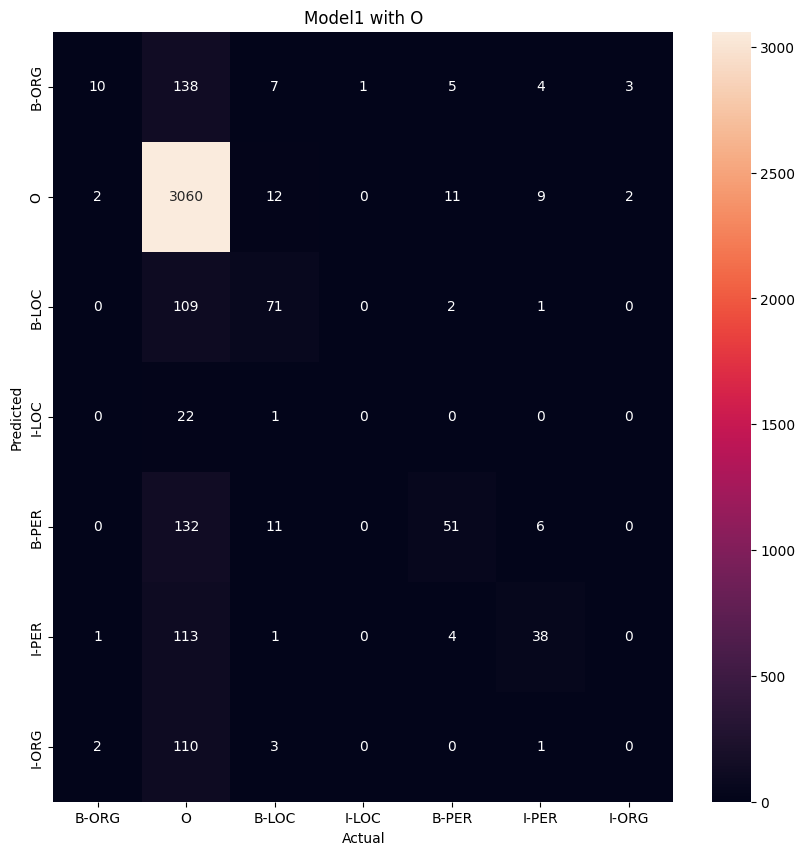

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.67      0.06      0.11       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.70      0.26      0.37       200
       B-LOC       0.67      0.39      0.49       183
       I-ORG       0.00      0.00      0.00       116
       I-PER       0.64      0.24      0.35       157

   micro avg       0.66      0.20      0.31       847
   macro avg       0.45      0.16      0.22       847
weighted avg       0.56      0.20      0.28       847



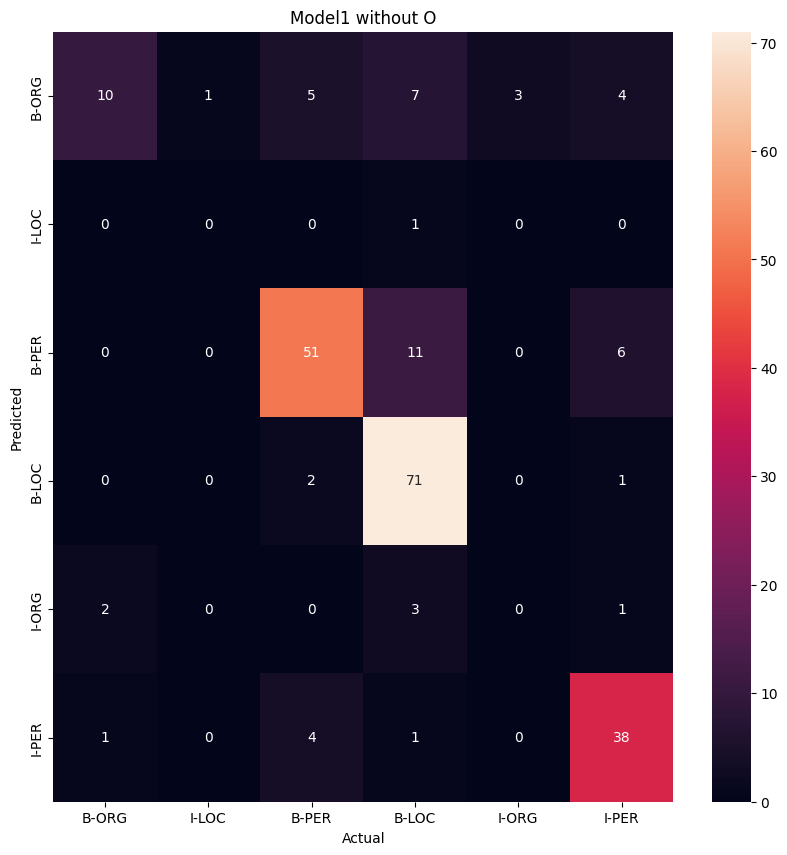

Epochs: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.40      0.01      0.02       168
           O       0.87      0.94      0.90      3096
       B-LOC       0.59      0.56      0.57       183
       I-LOC       0.33      0.04      0.08        23
       B-PER       0.42      0.37      0.39       200
       I-PER       0.36      0.50      0.42       157
       I-ORG       0.44      0.07      0.12       116

    accuracy                           0.81      3943
   macro avg       0.49      0.36      0.36      3943
weighted avg       0.78      0.81      0.78      3943



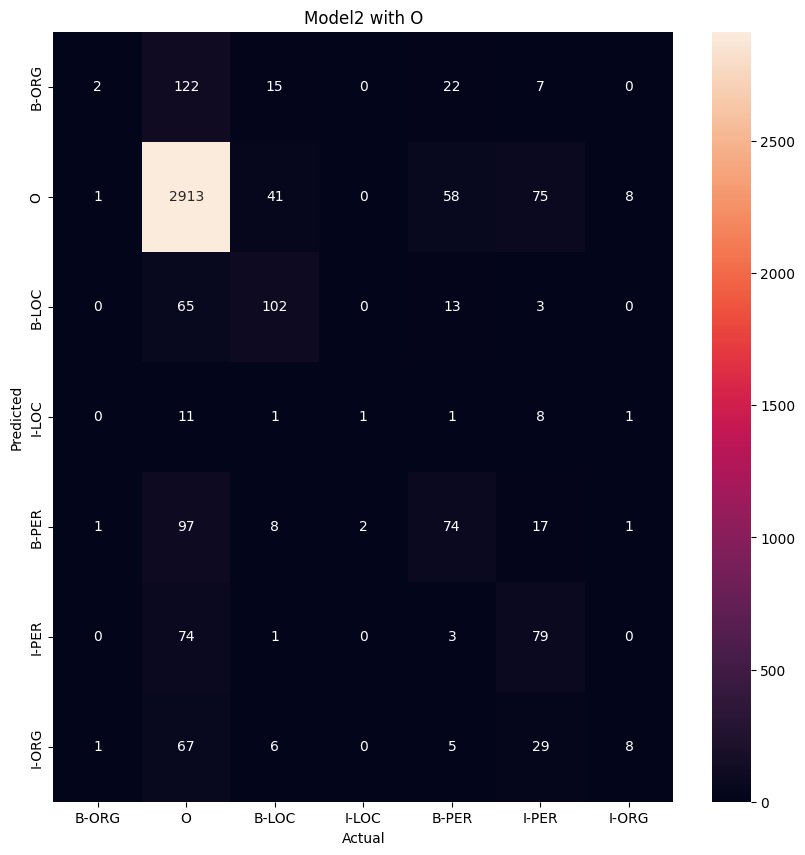

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.40      0.01      0.02       168
       I-LOC       0.33      0.04      0.08        23
       B-PER       0.42      0.37      0.39       200
       B-LOC       0.59      0.56      0.57       183
       I-ORG       0.44      0.07      0.12       116
       I-PER       0.36      0.50      0.42       157

   micro avg       0.45      0.31      0.37       847
   macro avg       0.42      0.26      0.27       847
weighted avg       0.44      0.31      0.32       847



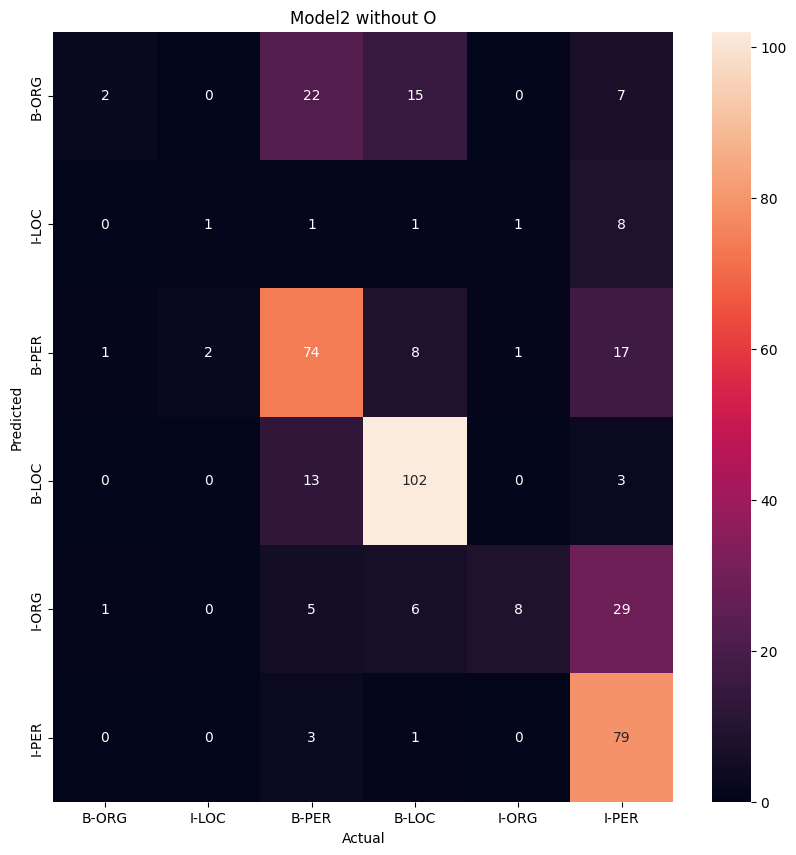

Epochs: 100%|██████████| 5/5 [00:11<00:00,  2.34s/it]


Training completed.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.50      0.01      0.01       168
           O       0.87      0.96      0.91      3096
       B-LOC       0.64      0.56      0.60       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.55      0.41      0.47       200
       I-PER       0.47      0.69      0.56       157
       I-ORG       0.29      0.02      0.03       116

    accuracy                           0.83      3943
   macro avg       0.47      0.38      0.37      3943
weighted avg       0.79      0.83      0.79      3943



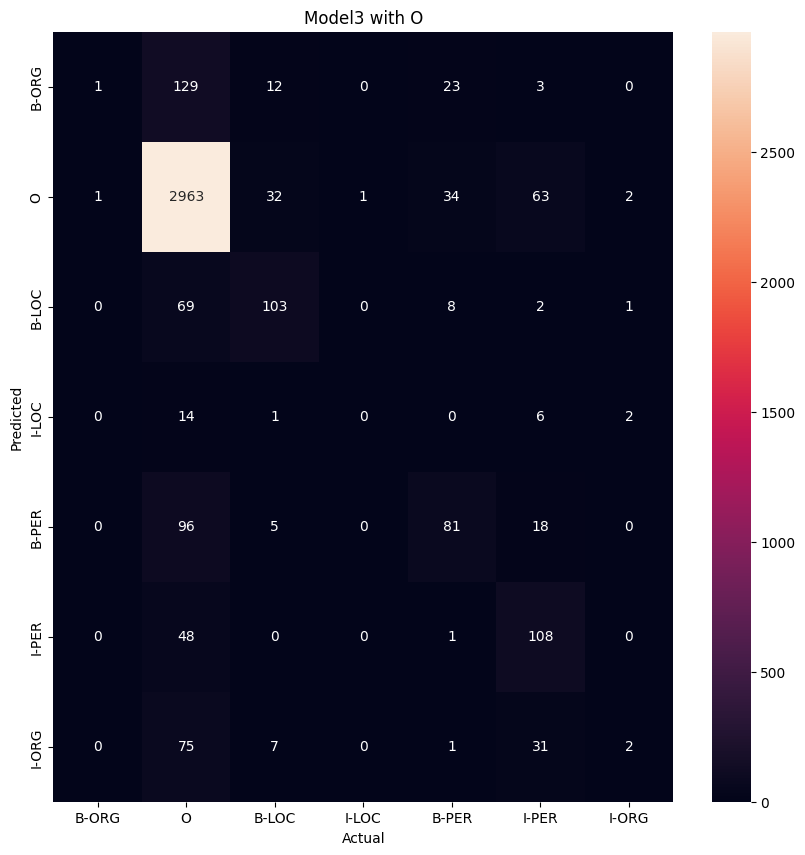

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.50      0.01      0.01       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.55      0.41      0.47       200
       B-LOC       0.64      0.56      0.60       183
       I-ORG       0.29      0.02      0.03       116
       I-PER       0.47      0.69      0.56       157

   micro avg       0.54      0.35      0.42       847
   macro avg       0.41      0.28      0.28       847
weighted avg       0.49      0.35      0.35       847



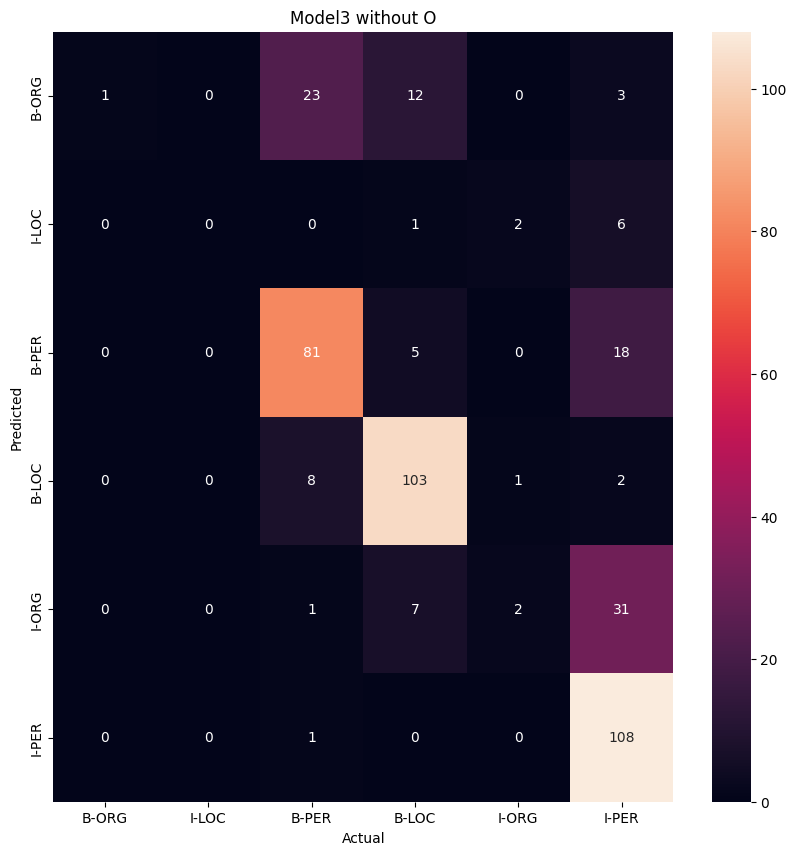

Epochs: 100%|██████████| 5/5 [00:07<00:00,  1.54s/it]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Training completed.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.45      0.32      0.37       168
           O       0.88      0.98      0.93      3096
       B-LOC       0.72      0.50      0.59       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.81      0.46      0.58       200
       I-PER       0.72      0.44      0.55       157
       I-ORG       0.91      0.09      0.16       116

    accuracy                           0.85      3943
   macro avg       0.64      0.40      0.45      3943
weighted avg       0.84      0.85      0.83      3943



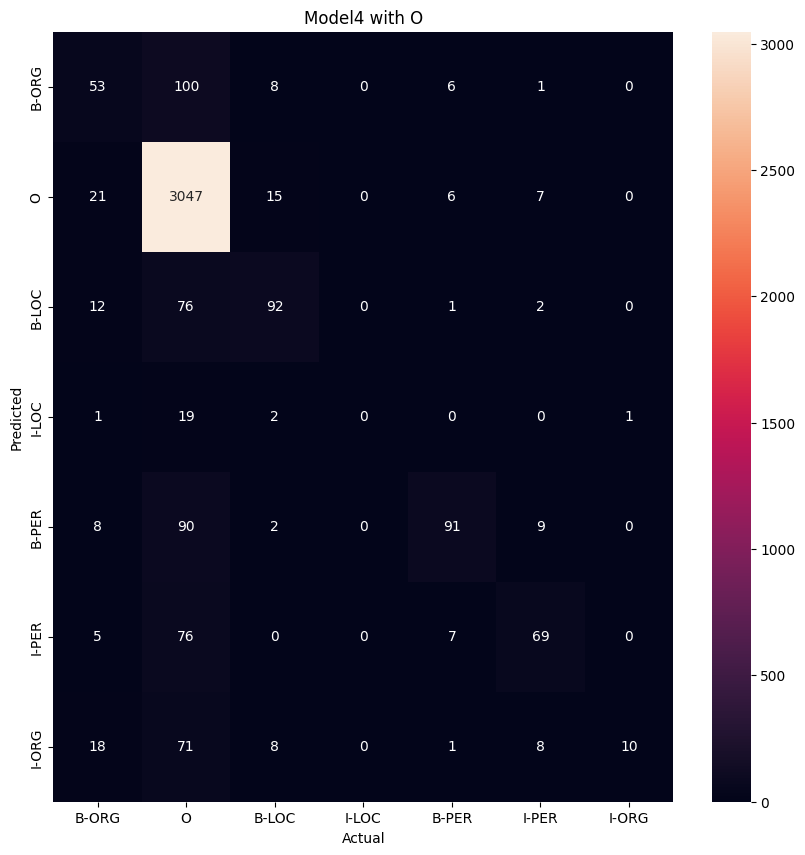

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.45      0.32      0.37       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.81      0.46      0.58       200
       B-LOC       0.72      0.50      0.59       183
       I-ORG       0.91      0.09      0.16       116
       I-PER       0.72      0.44      0.55       157

   micro avg       0.68      0.37      0.48       847
   macro avg       0.60      0.30      0.38       847
weighted avg       0.70      0.37      0.46       847



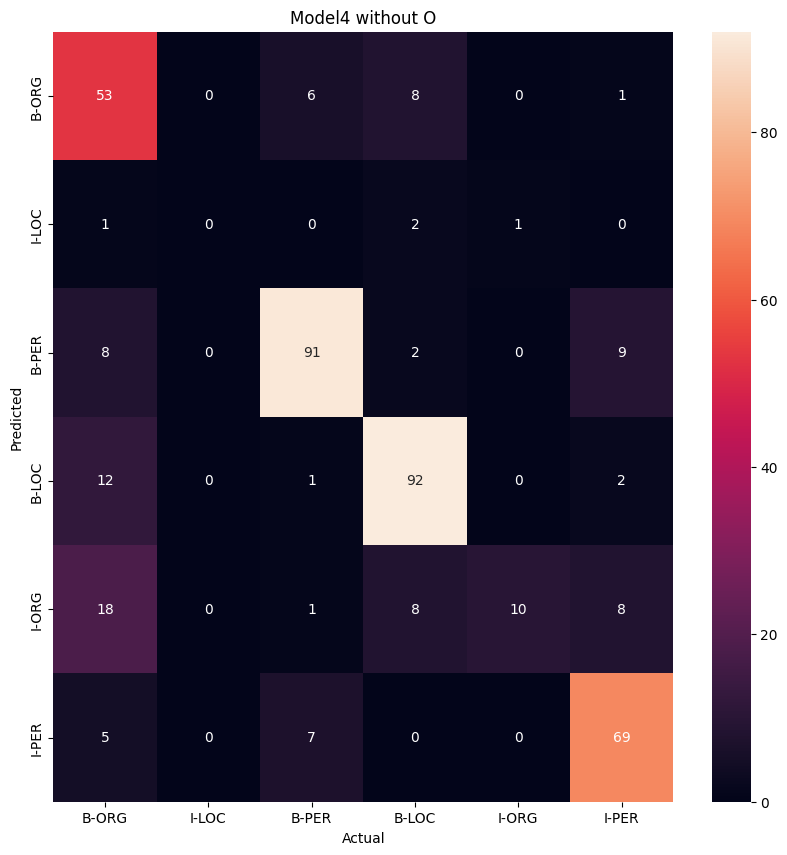

Epochs: 100%|██████████| 5/5 [00:17<00:00,  3.55s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.63      0.52      0.57       168
           O       0.95      0.93      0.94      3096
       B-LOC       0.51      0.75      0.61       183
       I-LOC       0.53      0.35      0.42        23
       B-PER       0.71      0.68      0.69       200
       I-PER       0.71      0.81      0.76       157
       I-ORG       0.48      0.43      0.45       116

    accuracy                           0.87      3943
   macro avg       0.65      0.64      0.63      3943
weighted avg       0.88      0.87      0.87      3943



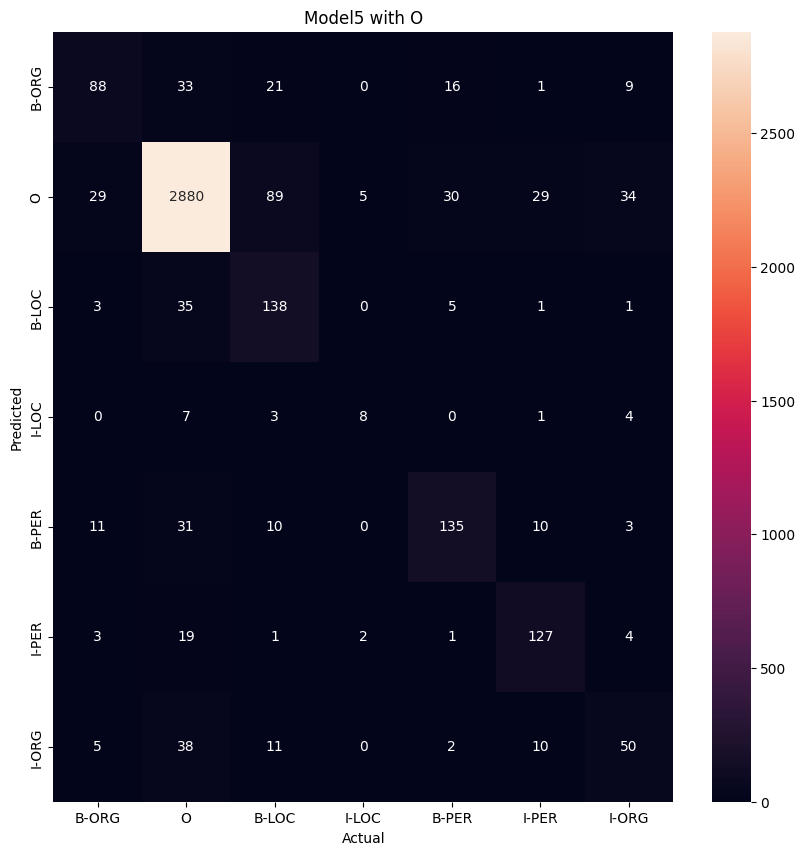

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.63      0.52      0.57       168
       I-LOC       0.53      0.35      0.42        23
       B-PER       0.71      0.68      0.69       200
       B-LOC       0.51      0.75      0.61       183
       I-ORG       0.48      0.43      0.45       116
       I-PER       0.71      0.81      0.76       157

   micro avg       0.61      0.64      0.63       847
   macro avg       0.60      0.59      0.58       847
weighted avg       0.61      0.64      0.62       847



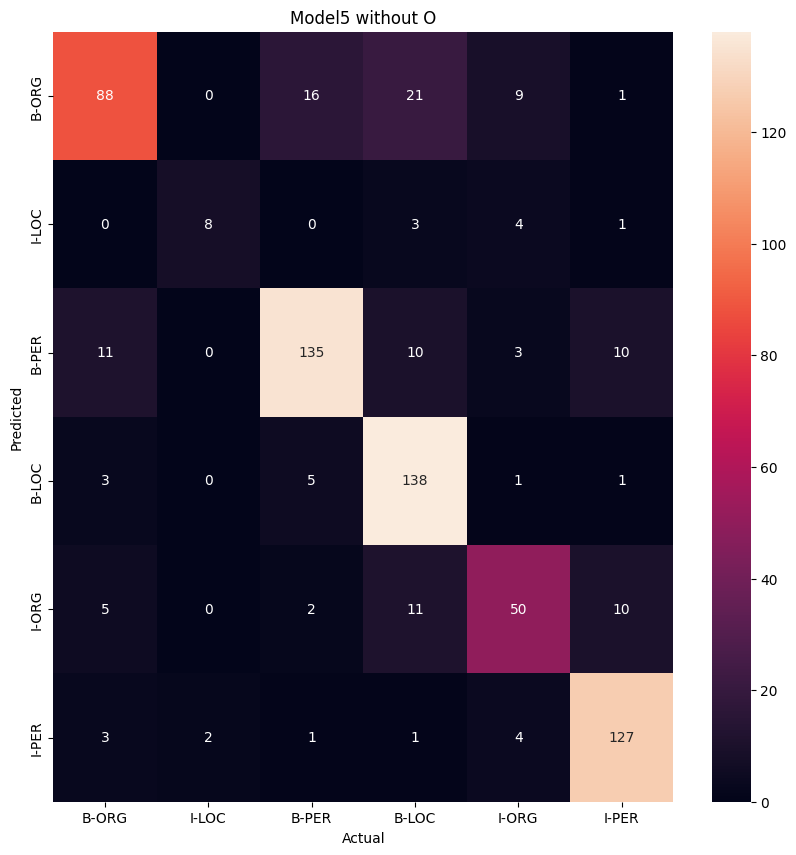

Epochs: 100%|██████████| 5/5 [00:26<00:00,  5.38s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.69      0.51      0.58       168
           O       0.89      0.98      0.93      3096
       B-LOC       0.77      0.55      0.64       183
       I-LOC       0.60      0.26      0.36        23
       B-PER       0.84      0.43      0.57       200
       I-PER       0.93      0.48      0.63       157
       I-ORG       0.63      0.32      0.42       116

    accuracy                           0.87      3943
   macro avg       0.76      0.50      0.59      3943
weighted avg       0.86      0.87      0.86      3943



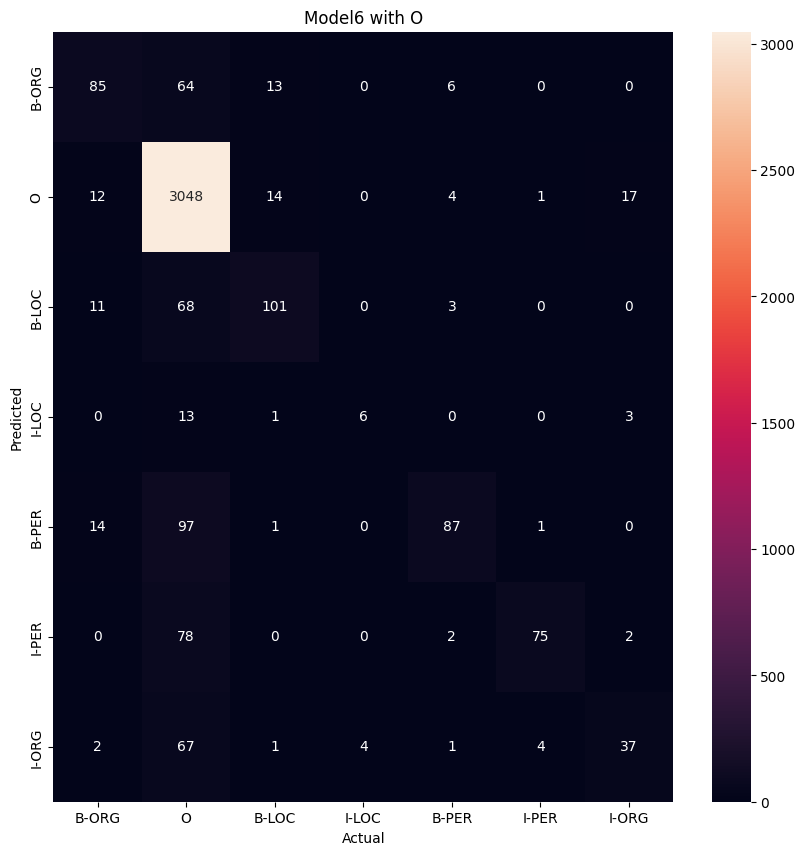

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.69      0.51      0.58       168
       I-LOC       0.60      0.26      0.36        23
       B-PER       0.84      0.43      0.57       200
       B-LOC       0.77      0.55      0.64       183
       I-ORG       0.63      0.32      0.42       116
       I-PER       0.93      0.48      0.63       157

   micro avg       0.77      0.46      0.58       847
   macro avg       0.74      0.43      0.54       847
weighted avg       0.78      0.46      0.57       847



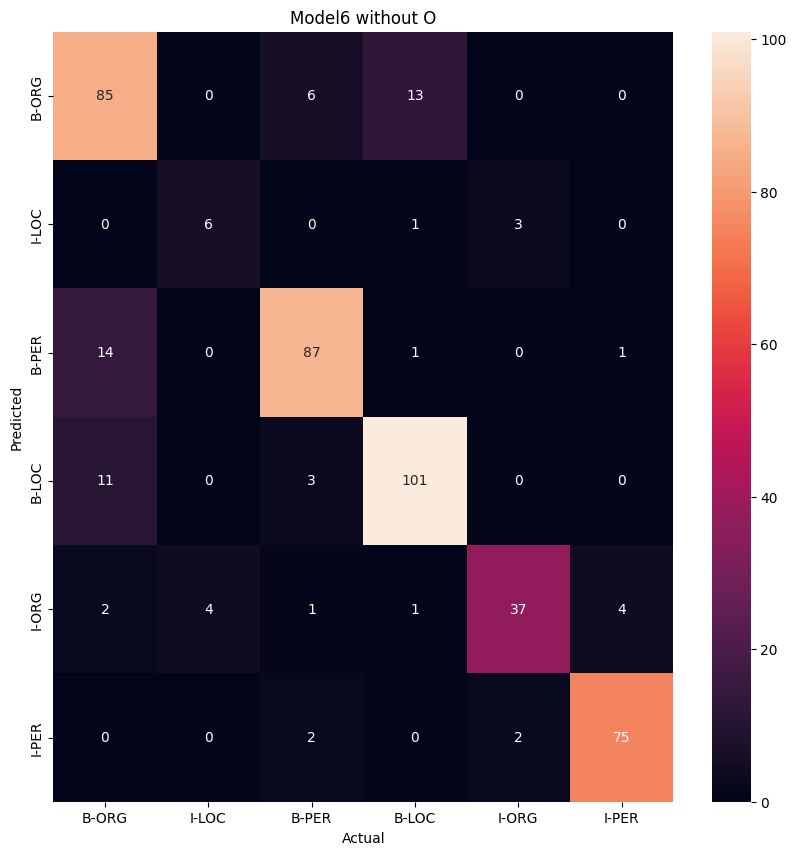

Epochs: 100%|██████████| 5/5 [00:16<00:00,  3.22s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.68      0.26      0.38       168
           O       0.89      0.98      0.93      3096
       B-LOC       0.70      0.60      0.65       183
       I-LOC       1.00      0.04      0.08        23
       B-PER       0.67      0.54      0.60       200
       I-PER       0.68      0.56      0.61       157
       I-ORG       0.75      0.10      0.18       116

    accuracy                           0.86      3943
   macro avg       0.77      0.44      0.49      3943
weighted avg       0.85      0.86      0.84      3943



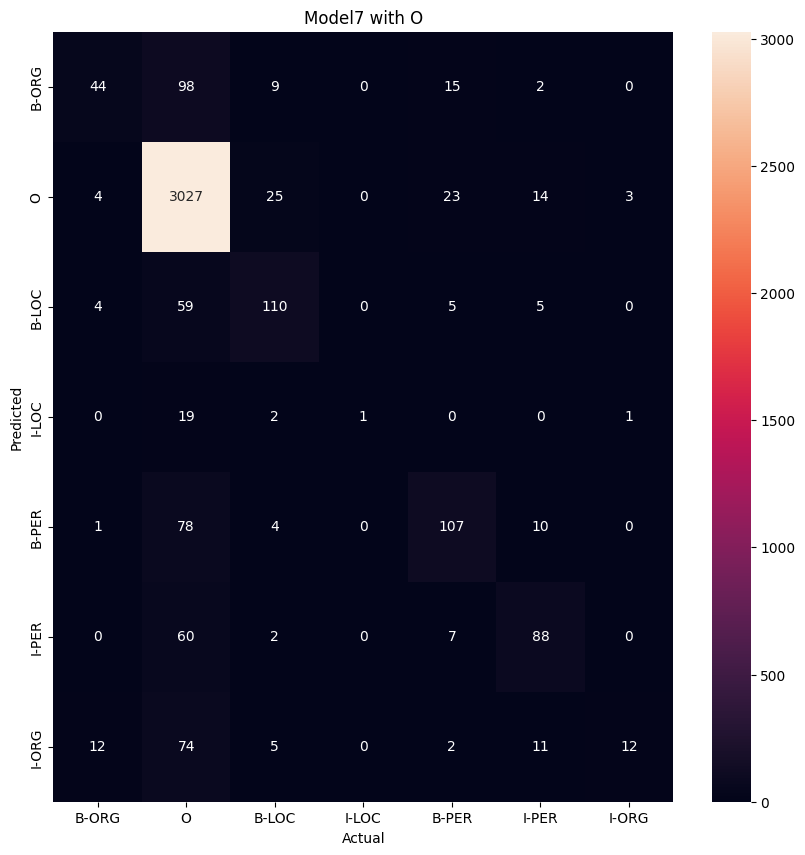

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.68      0.26      0.38       168
       I-LOC       1.00      0.04      0.08        23
       B-PER       0.67      0.54      0.60       200
       B-LOC       0.70      0.60      0.65       183
       I-ORG       0.75      0.10      0.18       116
       I-PER       0.68      0.56      0.61       157

   micro avg       0.69      0.43      0.53       847
   macro avg       0.75      0.35      0.42       847
weighted avg       0.70      0.43      0.50       847



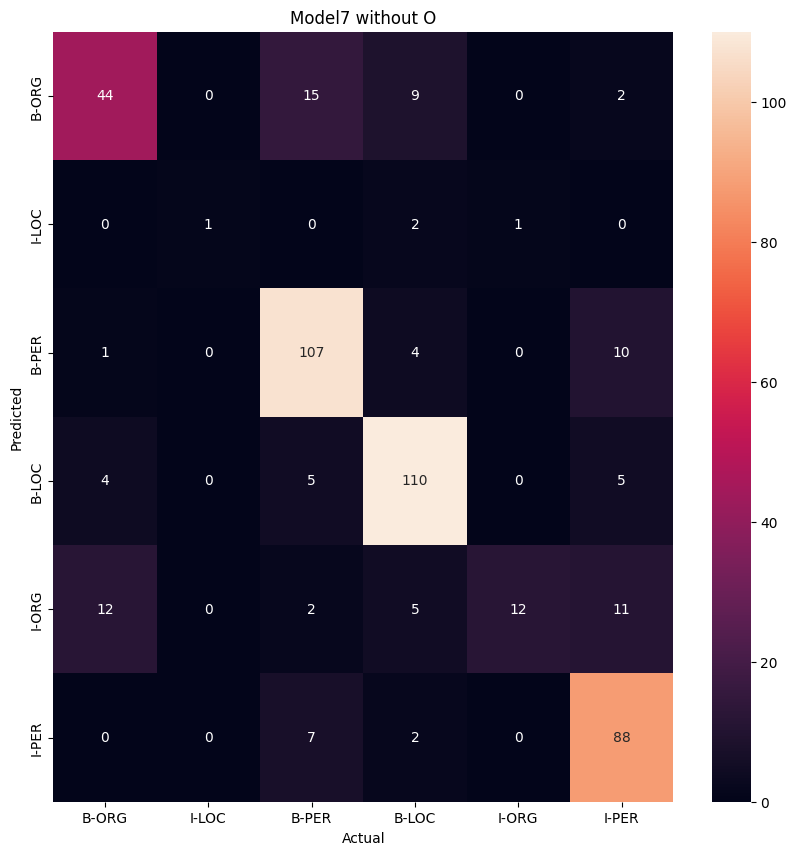

Epochs: 100%|██████████| 5/5 [00:39<00:00,  7.99s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.59      0.53      0.56       168
           O       0.93      0.95      0.94      3096
       B-LOC       0.61      0.73      0.66       183
       I-LOC       0.75      0.52      0.62        23
       B-PER       0.72      0.73      0.73       200
       I-PER       0.81      0.73      0.77       157
       I-ORG       0.64      0.38      0.48       116

    accuracy                           0.88      3943
   macro avg       0.72      0.65      0.68      3943
weighted avg       0.88      0.88      0.88      3943



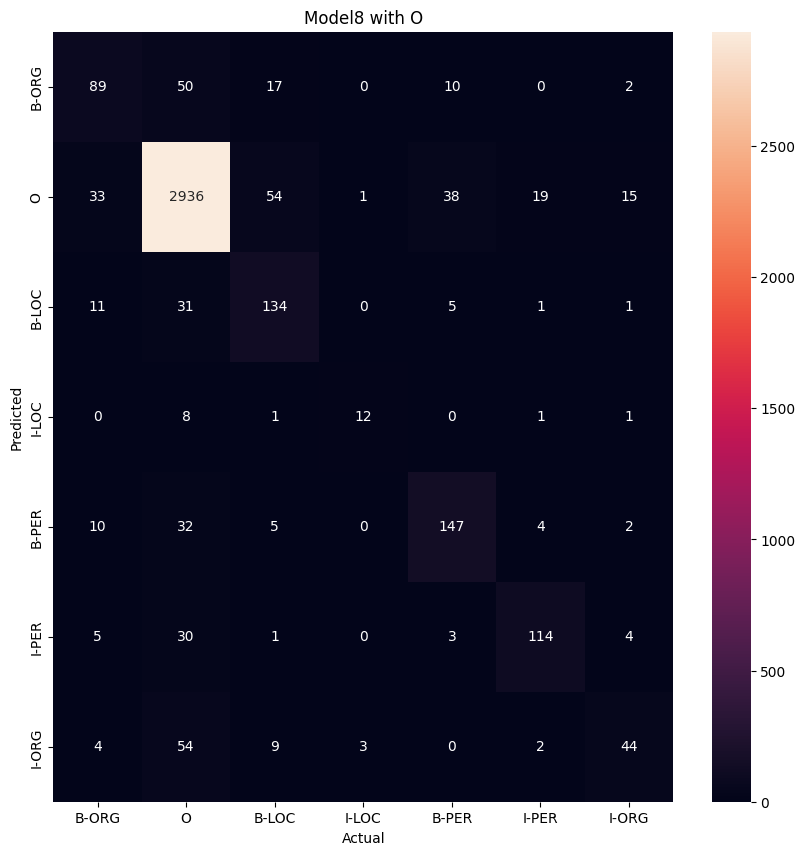

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.59      0.53      0.56       168
       I-LOC       0.75      0.52      0.62        23
       B-PER       0.72      0.73      0.73       200
       B-LOC       0.61      0.73      0.66       183
       I-ORG       0.64      0.38      0.48       116
       I-PER       0.81      0.73      0.77       157

   micro avg       0.67      0.64      0.65       847
   macro avg       0.69      0.60      0.63       847
weighted avg       0.68      0.64      0.65       847



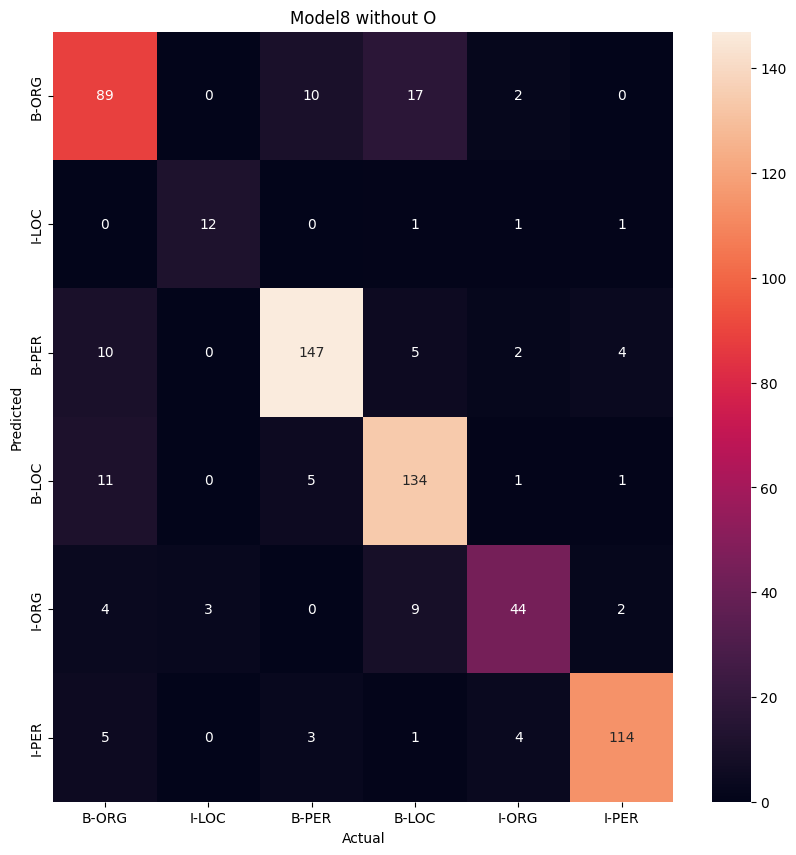

Epochs: 100%|██████████| 5/5 [01:04<00:00, 12.92s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.78      0.50      0.61       168
           O       0.90      0.99      0.95      3096
       B-LOC       0.78      0.66      0.71       183
       I-LOC       0.73      0.35      0.47        23
       B-PER       0.88      0.60      0.72       200
       I-PER       0.93      0.57      0.71       157
       I-ORG       0.84      0.27      0.41       116

    accuracy                           0.90      3943
   macro avg       0.83      0.56      0.65      3943
weighted avg       0.89      0.90      0.88      3943



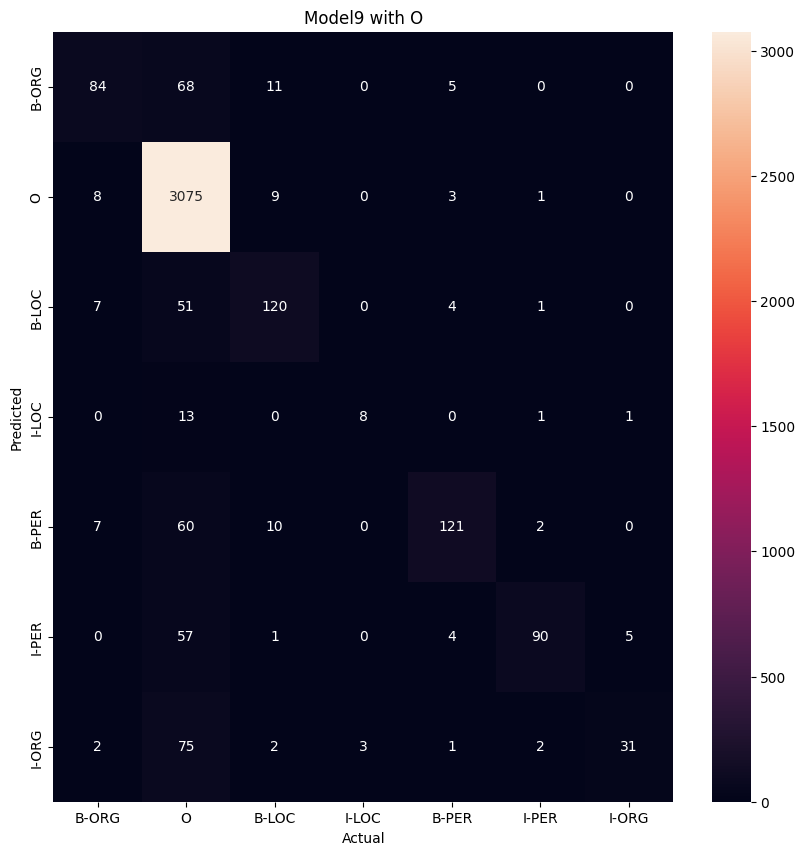

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.78      0.50      0.61       168
       I-LOC       0.73      0.35      0.47        23
       B-PER       0.88      0.60      0.72       200
       B-LOC       0.78      0.66      0.71       183
       I-ORG       0.84      0.27      0.41       116
       I-PER       0.93      0.57      0.71       157

   micro avg       0.83      0.54      0.65       847
   macro avg       0.82      0.49      0.60       847
weighted avg       0.84      0.54      0.64       847



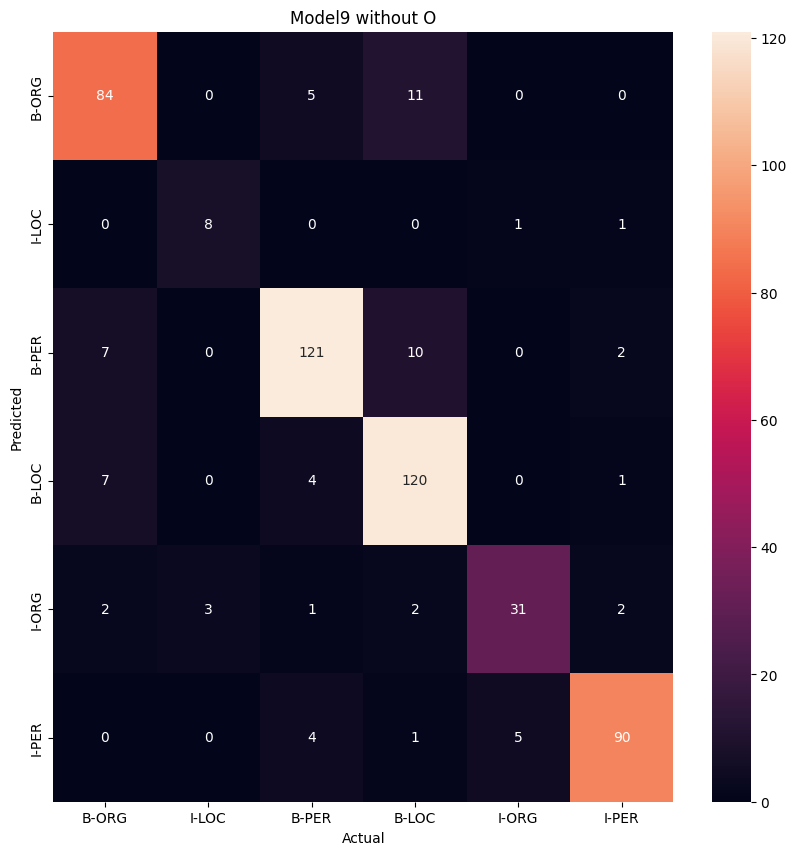

+-------------+----------+--------+------------------+---------------+-----------+------------------+---------------+------------+--------------+
|   PERCISION |   RECALL |     F1 |   PERCISION_WO_O |   RECALL_WO_O |   F1_WO_O |   embedding_size |   hidden_size |   n_layers |   directions |
|-------------+----------+--------+------------------+---------------+-----------+------------------+---------------+------------+--------------|
|      0.7728 |   0.8192 | 0.7692 |           0.7549 |        0.7623 |    0.7418 |              300 |           500 |          1 |            1 |
|      0.7780 |   0.8062 | 0.7780 |           0.6500 |        0.6472 |    0.5875 |              300 |           500 |          2 |            1 |
|      0.7914 |   0.8263 | 0.7921 |           0.6998 |        0.7091 |    0.6366 |              300 |           500 |          3 |            1 |
|      0.8370 |   0.8527 | 0.8270 |           0.7788 |        0.7590 |    0.7424 |              300 |           500 |       

In [ ]:
# Define models with their hyperparameters
models = {
  'Model1': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 1},
  'Model2': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 1},
  'Model3': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 1},
  'Model4': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 2},
  'Model5': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 2},
  'Model6': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 2},
  'Model7': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 1, 'directions': 2},
  'Model8': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 2, 'directions': 2},
  'Model9': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 3, 'directions': 2},
}

# TO DO ----------------------------------------------------------------------
results_dev = []
for model_name, hyperparameters in models.items():
  model = NERNet(input_size=vocab.n_words, embedding_size=hyperparameters['embedding_size'],
                 hidden_size=hyperparameters['hidden_size'],
                 n_layers=hyperparameters['n_layers'],
                directions=hyperparameters['directions'],
                 output_size=vocab.n_tags)
  metrics = train_loop(model, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
  results = evaluate(model, model_name, dl_dev, vocab)
  results_dev.append({**results, **hyperparameters})
  # save_model_with_config(model, model_name, hyperparameters)
  # trained_models[model_name] = model

# TO DO ----------------------------------------------------------------------

# Print results in tabulated format
print(tabulate(results_dev, headers='keys', tablefmt='psql', floatfmt=".4f"))

## Step 3: Evaluate on Test Set
Evaluate your models on the test set and save the results as a CSV. Add this file to your repo for submission.

Epochs: 100%|██████████| 5/5 [00:04<00:00,  1.05it/s]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.75      0.02      0.03       168
           O       0.82      0.99      0.90      3096
       B-LOC       0.68      0.39      0.49       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.77      0.24      0.37       200
       I-PER       0.53      0.15      0.24       157
       I-ORG       0.33      0.01      0.02       116

    accuracy                           0.82      3943
   macro avg       0.55      0.26      0.29      3943
weighted avg       0.78      0.82      0.76      3943



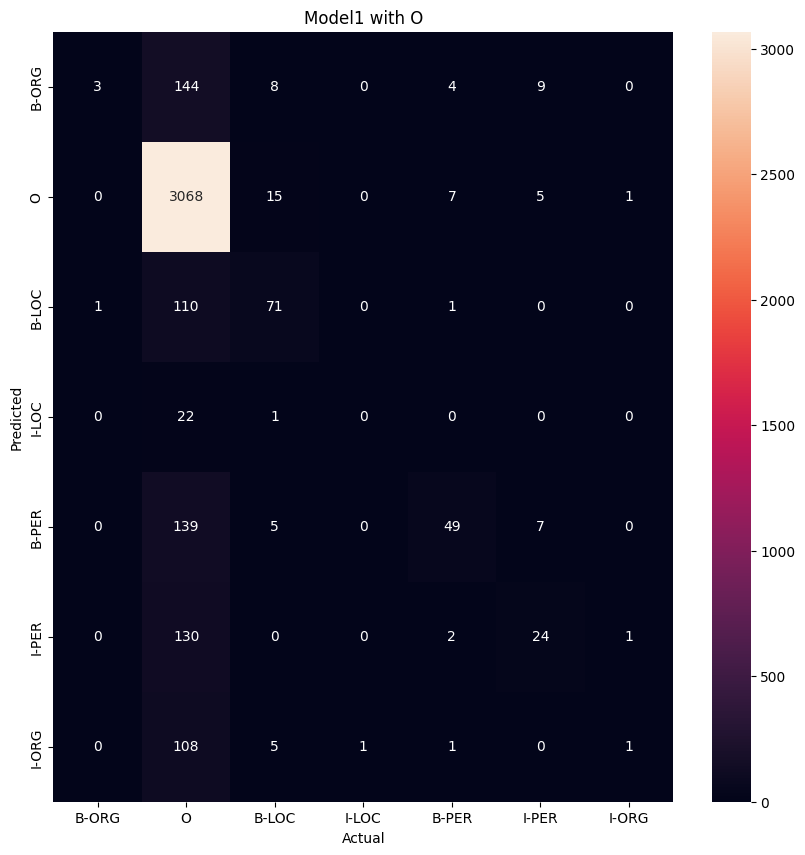

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.75      0.02      0.03       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.77      0.24      0.37       200
       B-LOC       0.68      0.39      0.49       183
       I-ORG       0.33      0.01      0.02       116
       I-PER       0.53      0.15      0.24       157

   micro avg       0.67      0.17      0.28       847
   macro avg       0.51      0.14      0.19       847
weighted avg       0.62      0.17      0.25       847



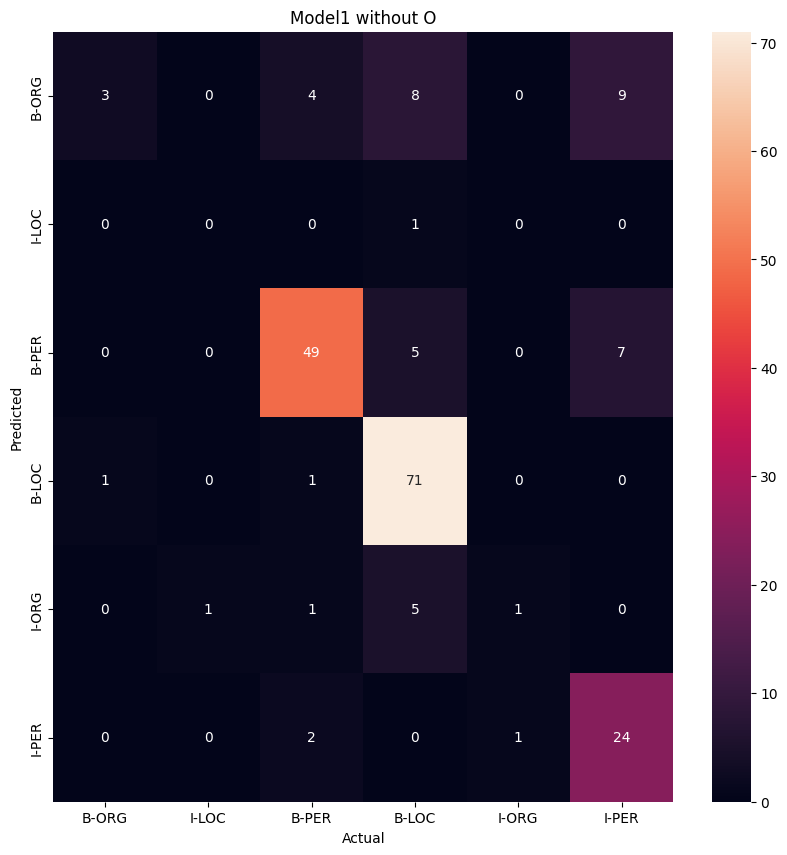

/tmp/ipython-input-24-4218197998.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)
Epochs: 100%|██████████| 5/5 [00:08<00:00,  1.70s/it]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

Training completed.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.73      0.05      0.09       168
           O       0.84      0.99      0.91      3096
       B-LOC       0.75      0.42      0.54       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.69      0.28      0.39       200
       I-PER       0.61      0.33      0.43       157
       I-ORG       0.83      0.04      0.08       116

    accuracy                           0.83      3943
   macro avg       0.64      0.30      0.35      3943
weighted avg       0.81      0.83      0.78      3943



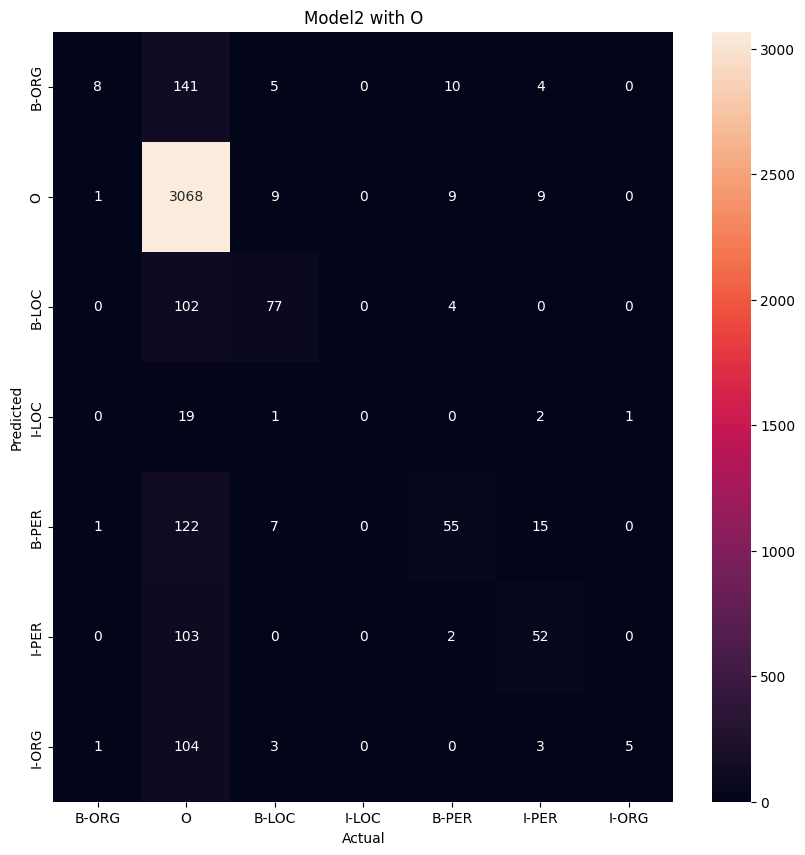

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.73      0.05      0.09       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.69      0.28      0.39       200
       B-LOC       0.75      0.42      0.54       183
       I-ORG       0.83      0.04      0.08       116
       I-PER       0.61      0.33      0.43       157

   micro avg       0.69      0.23      0.35       847
   macro avg       0.60      0.19      0.26       847
weighted avg       0.70      0.23      0.32       847



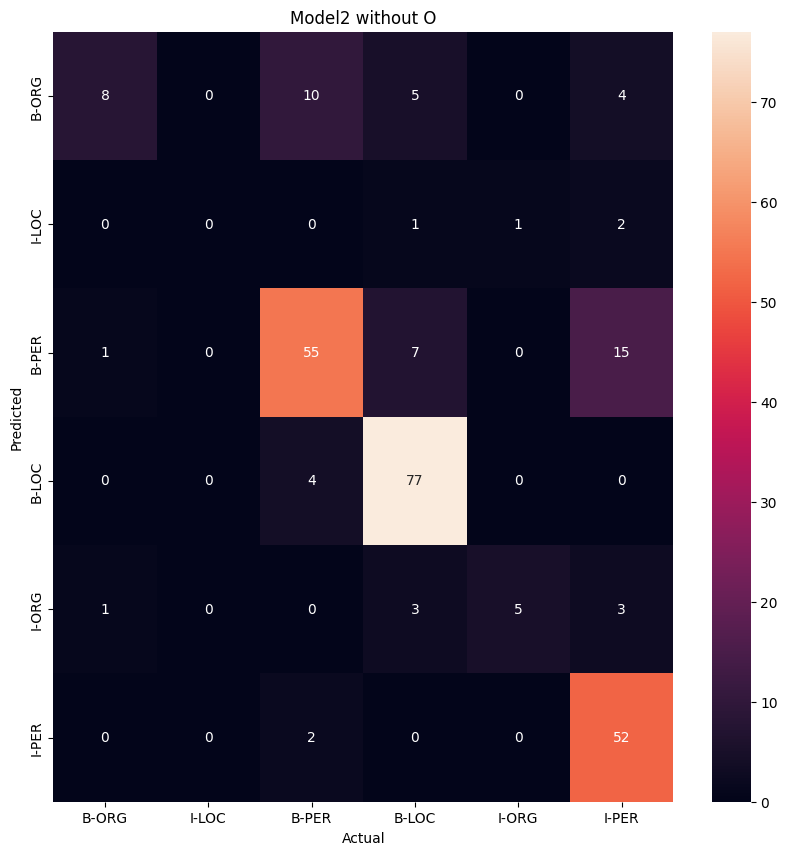

Epochs: 100%|██████████| 5/5 [00:11<00:00,  2.36s/it]


Training completed.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.00      0.00      0.00       168
           O       0.86      0.96      0.91      3096
       B-LOC       0.60      0.48      0.53       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.52      0.38      0.44       200
       I-PER       0.46      0.56      0.50       157
       I-ORG       0.25      0.01      0.02       116

    accuracy                           0.82      3943
   macro avg       0.38      0.34      0.34      3943
weighted avg       0.76      0.82      0.78      3943



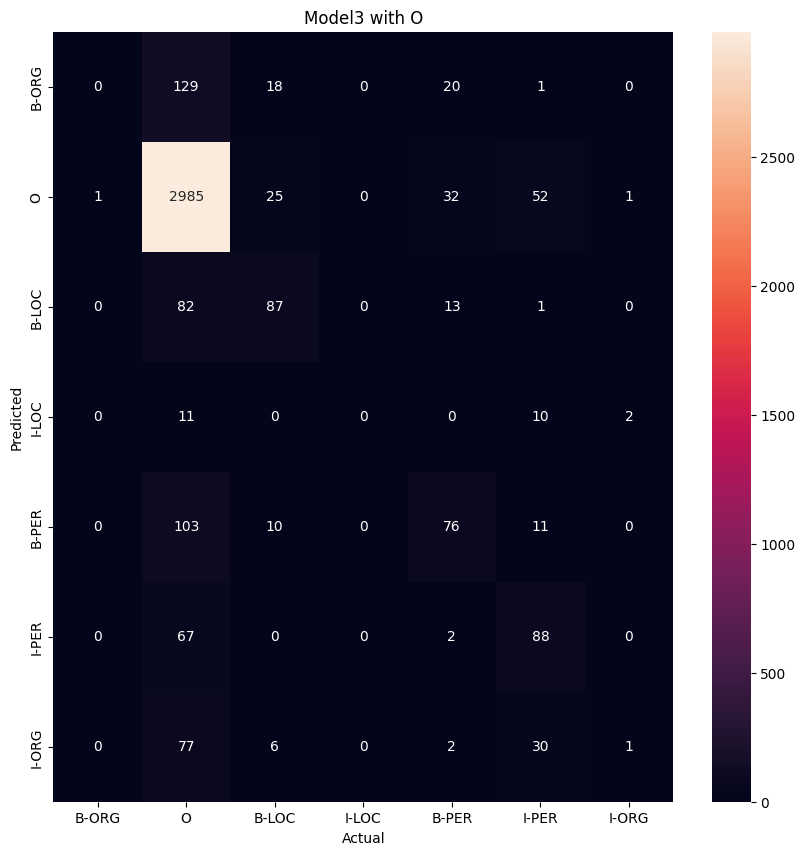

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.00      0.00      0.00       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.52      0.38      0.44       200
       B-LOC       0.60      0.48      0.53       183
       I-ORG       0.25      0.01      0.02       116
       I-PER       0.46      0.56      0.50       157

   micro avg       0.52      0.30      0.38       847
   macro avg       0.30      0.24      0.25       847
weighted avg       0.37      0.30      0.31       847



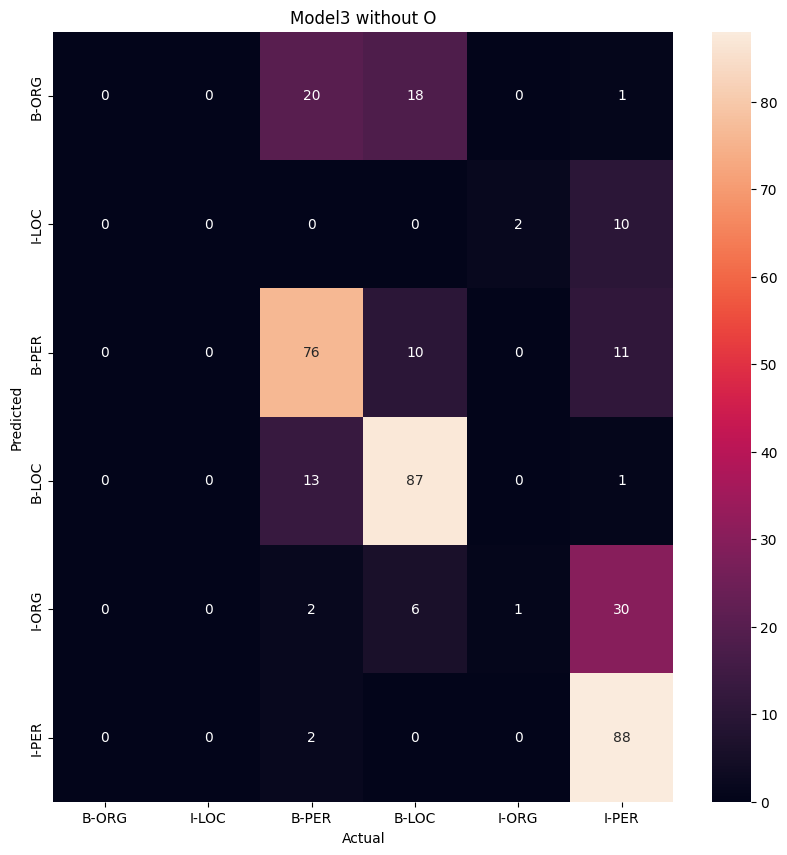

Epochs: 100%|██████████| 5/5 [00:07<00:00,  1.55s/it]


Training completed.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.70      0.19      0.30       168
           O       0.85      0.99      0.92      3096
       B-LOC       0.78      0.42      0.54       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.85      0.40      0.54       200
       I-PER       0.69      0.43      0.53       157
       I-ORG       0.00      0.00      0.00       116

    accuracy                           0.85      3943
   macro avg       0.55      0.35      0.41      3943
weighted avg       0.81      0.85      0.81      3943



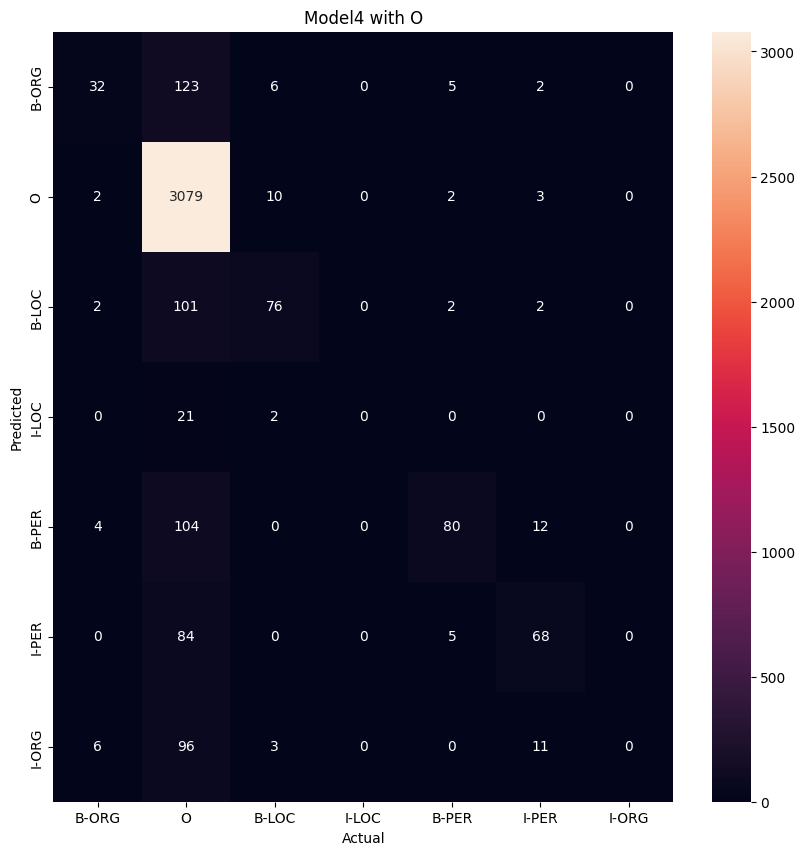

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.70      0.19      0.30       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.85      0.40      0.54       200
       B-LOC       0.78      0.42      0.54       183
       I-ORG       0.00      0.00      0.00       116
       I-PER       0.69      0.43      0.53       157

   micro avg       0.76      0.30      0.43       847
   macro avg       0.50      0.24      0.32       847
weighted avg       0.64      0.30      0.40       847



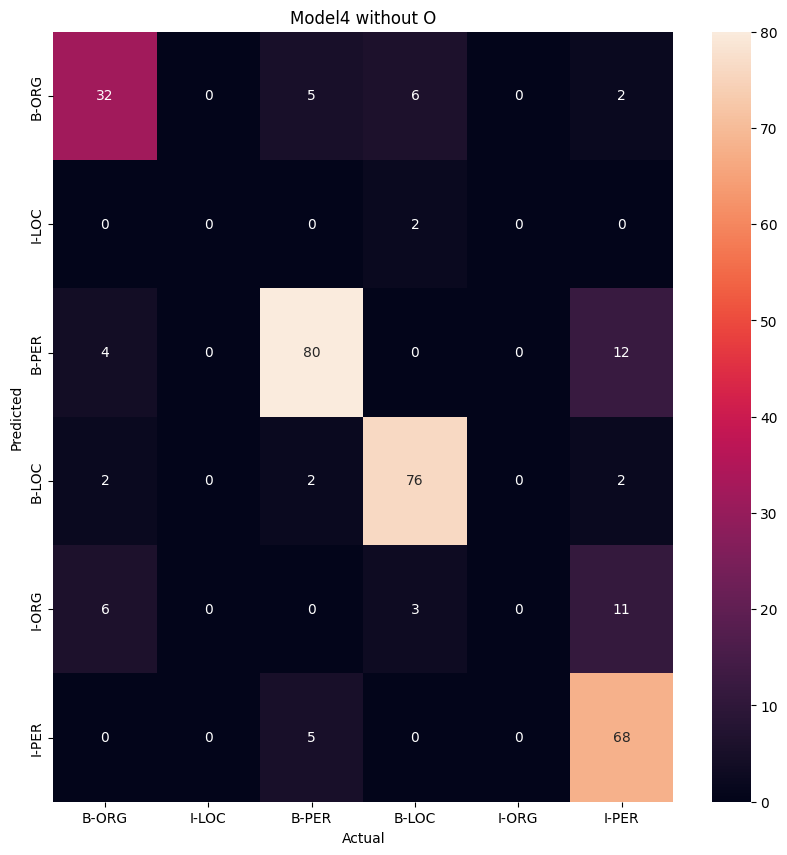

Epochs: 100%|██████████| 5/5 [00:17<00:00,  3.45s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.76      0.42      0.54       168
           O       0.93      0.96      0.94      3096
       B-LOC       0.85      0.50      0.63       183
       I-LOC       0.83      0.22      0.34        23
       B-PER       0.55      0.73      0.63       200
       I-PER       0.55      0.79      0.65       157
       I-ORG       0.70      0.27      0.39       116

    accuracy                           0.87      3943
   macro avg       0.74      0.56      0.59      3943
weighted avg       0.87      0.87      0.86      3943



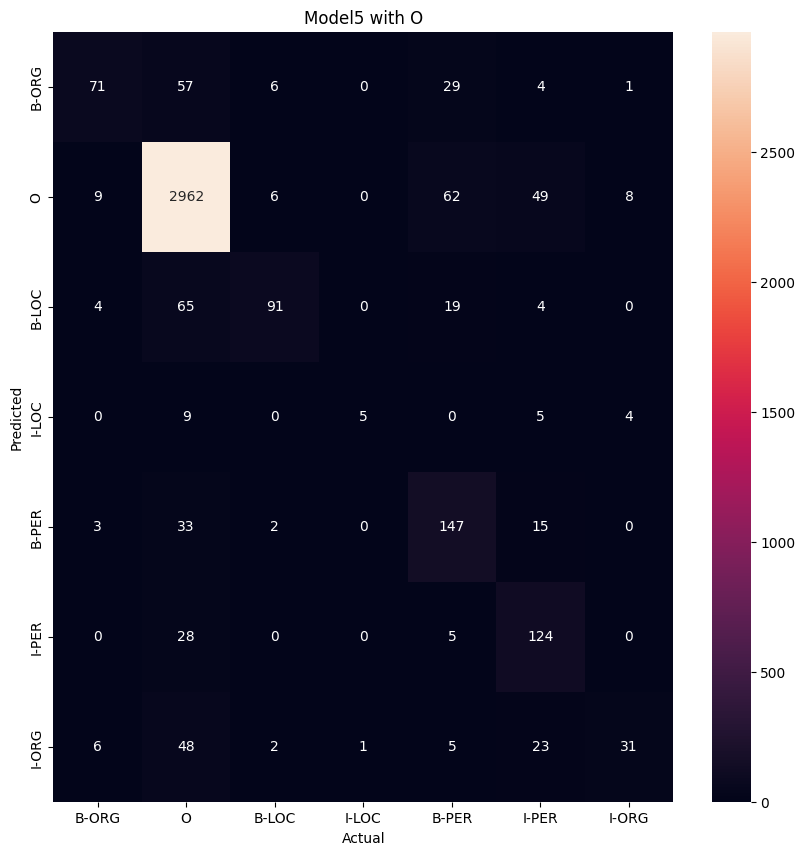

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.76      0.42      0.54       168
       I-LOC       0.83      0.22      0.34        23
       B-PER       0.55      0.73      0.63       200
       B-LOC       0.85      0.50      0.63       183
       I-ORG       0.70      0.27      0.39       116
       I-PER       0.55      0.79      0.65       157

   micro avg       0.63      0.55      0.59       847
   macro avg       0.71      0.49      0.53       847
weighted avg       0.69      0.55      0.58       847



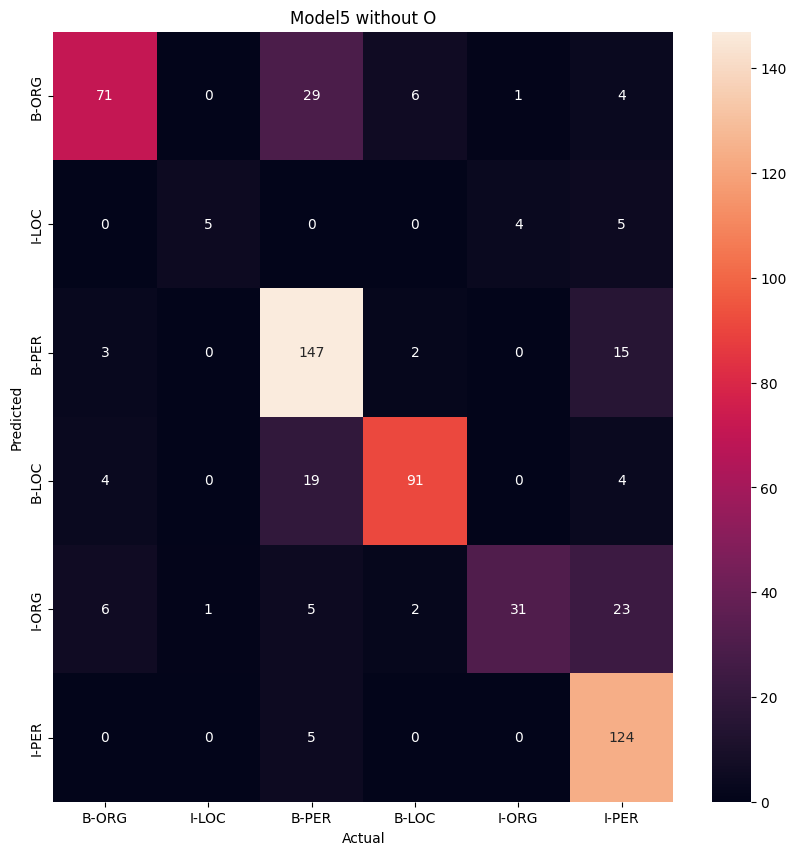

Epochs: 100%|██████████| 5/5 [00:26<00:00,  5.34s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.85      0.43      0.57       168
           O       0.92      0.98      0.95      3096
       B-LOC       0.70      0.73      0.71       183
       I-LOC       0.69      0.39      0.50        23
       B-PER       0.78      0.71      0.75       200
       I-PER       0.90      0.70      0.79       157
       I-ORG       0.91      0.26      0.40       116

    accuracy                           0.90      3943
   macro avg       0.82      0.60      0.67      3943
weighted avg       0.89      0.90      0.89      3943



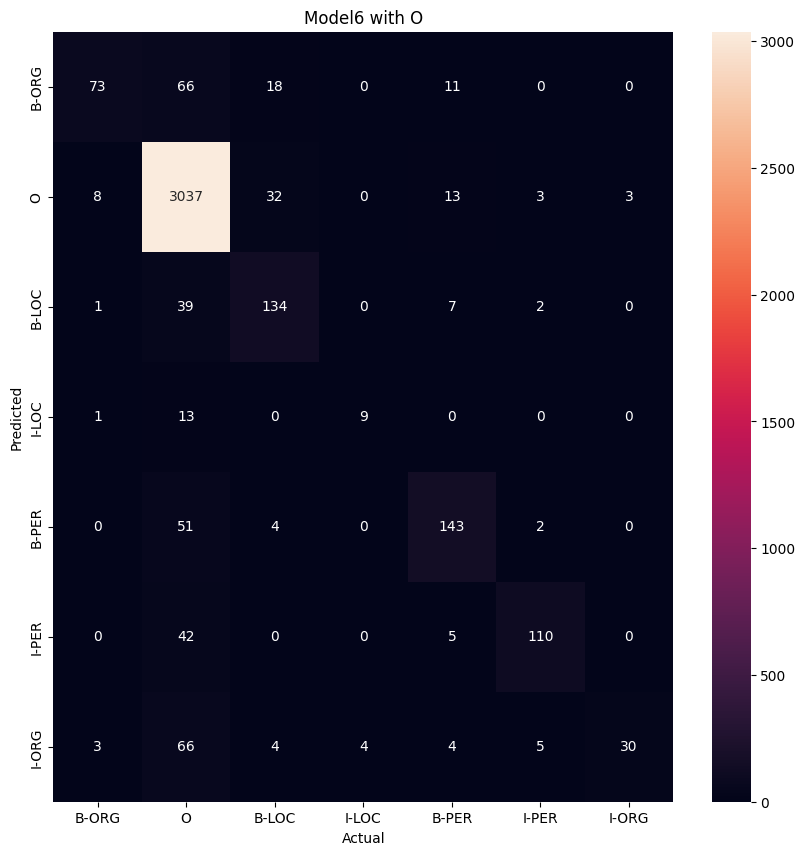

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.85      0.43      0.57       168
       I-LOC       0.69      0.39      0.50        23
       B-PER       0.78      0.71      0.75       200
       B-LOC       0.70      0.73      0.71       183
       I-ORG       0.91      0.26      0.40       116
       I-PER       0.90      0.70      0.79       157

   micro avg       0.79      0.59      0.68       847
   macro avg       0.81      0.54      0.62       847
weighted avg       0.81      0.59      0.66       847



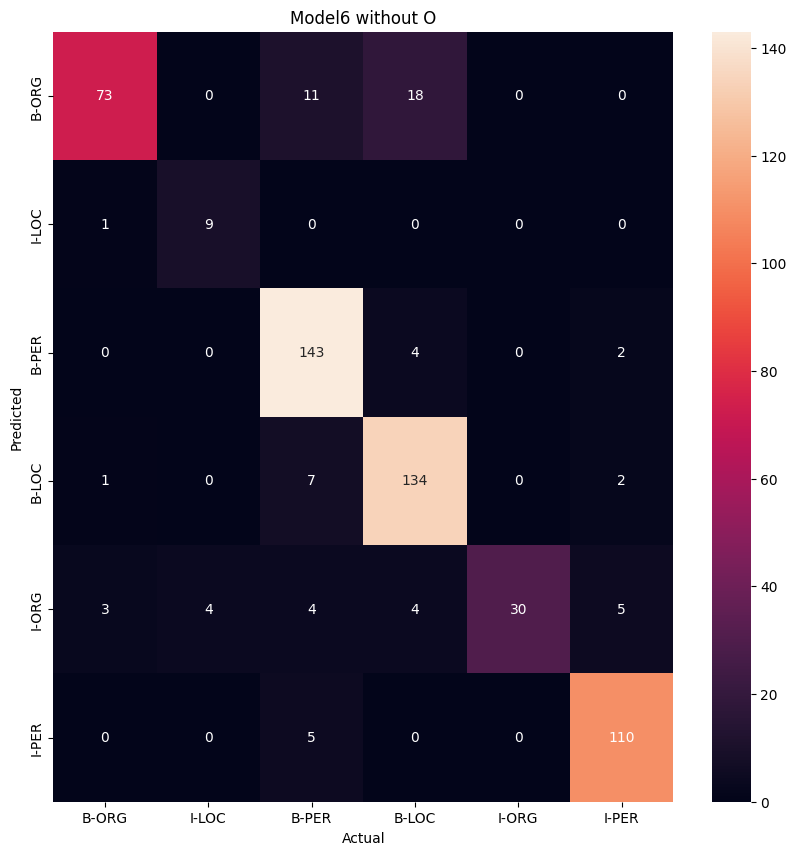

Epochs: 100%|██████████| 5/5 [00:16<00:00,  3.22s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.53      0.43      0.48       168
           O       0.87      0.99      0.93      3096
       B-LOC       0.84      0.42      0.56       183
       I-LOC       1.00      0.04      0.08        23
       B-PER       0.77      0.42      0.54       200
       I-PER       0.78      0.47      0.59       157
       I-ORG       0.93      0.12      0.21       116

    accuracy                           0.86      3943
   macro avg       0.82      0.41      0.48      3943
weighted avg       0.85      0.86      0.83      3943



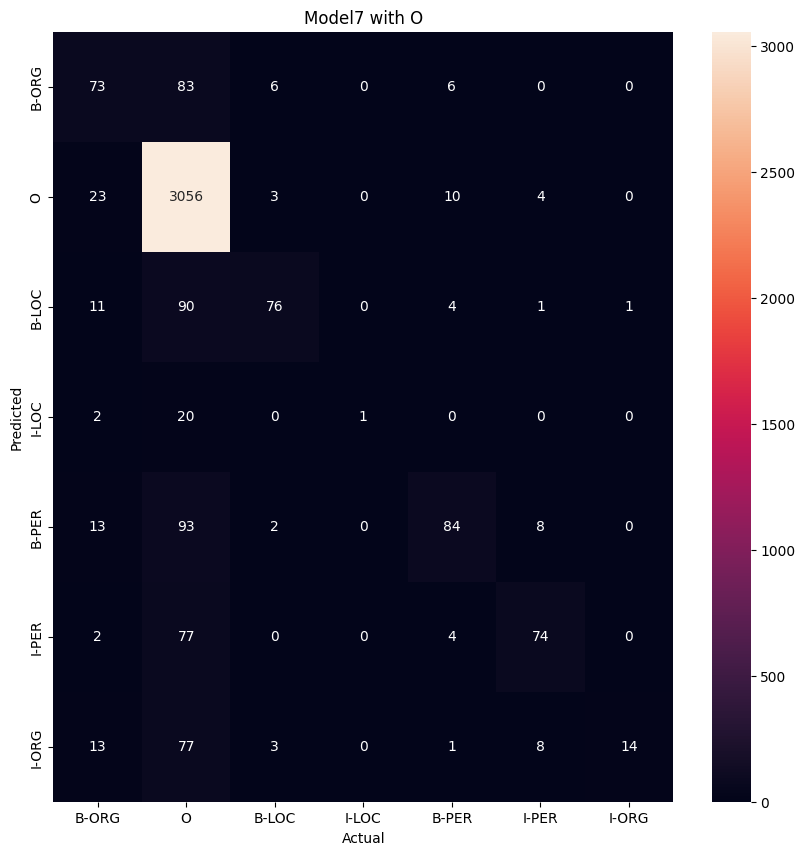

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.53      0.43      0.48       168
       I-LOC       1.00      0.04      0.08        23
       B-PER       0.77      0.42      0.54       200
       B-LOC       0.84      0.42      0.56       183
       I-ORG       0.93      0.12      0.21       116
       I-PER       0.78      0.47      0.59       157

   micro avg       0.72      0.38      0.50       847
   macro avg       0.81      0.32      0.41       847
weighted avg       0.77      0.38      0.48       847



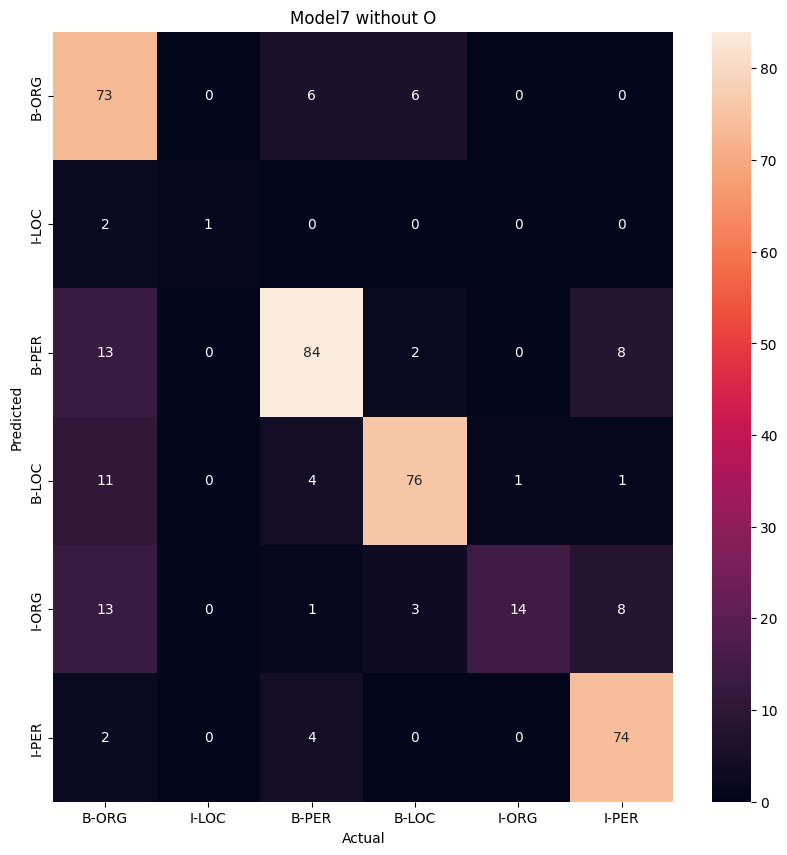

Epochs: 100%|██████████| 5/5 [00:40<00:00,  8.15s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.63      0.53      0.57       168
           O       0.93      0.95      0.94      3096
       B-LOC       0.61      0.73      0.66       183
       I-LOC       0.73      0.35      0.47        23
       B-PER       0.77      0.70      0.73       200
       I-PER       0.90      0.66      0.76       157
       I-ORG       0.43      0.45      0.44       116

    accuracy                           0.88      3943
   macro avg       0.71      0.62      0.65      3943
weighted avg       0.88      0.88      0.88      3943



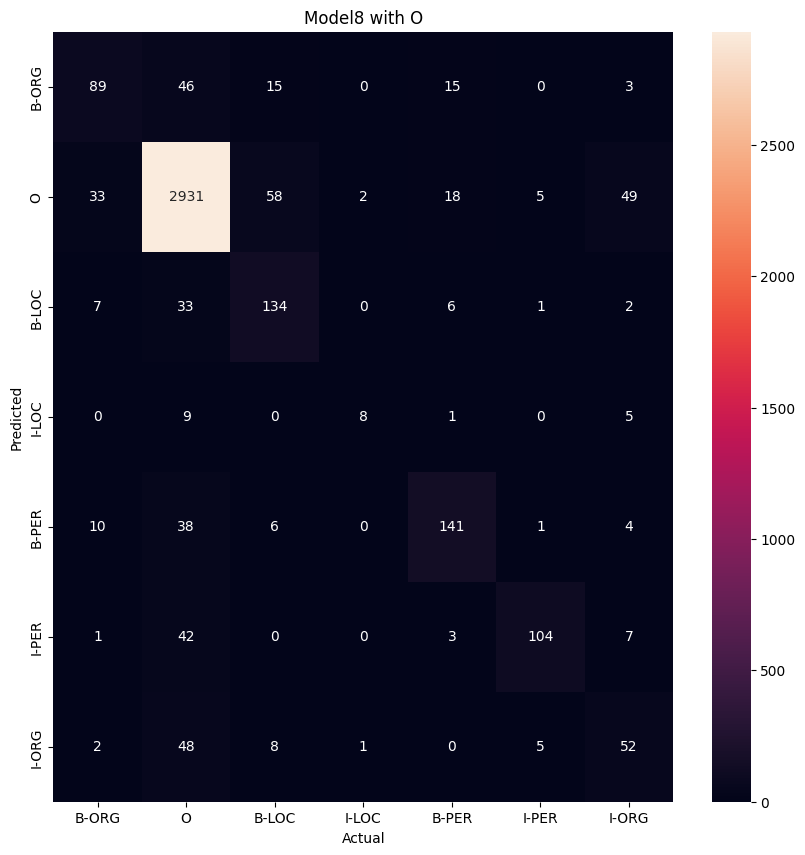

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.63      0.53      0.57       168
       I-LOC       0.73      0.35      0.47        23
       B-PER       0.77      0.70      0.73       200
       B-LOC       0.61      0.73      0.66       183
       I-ORG       0.43      0.45      0.44       116
       I-PER       0.90      0.66      0.76       157

   micro avg       0.66      0.62      0.64       847
   macro avg       0.67      0.57      0.61       847
weighted avg       0.68      0.62      0.64       847



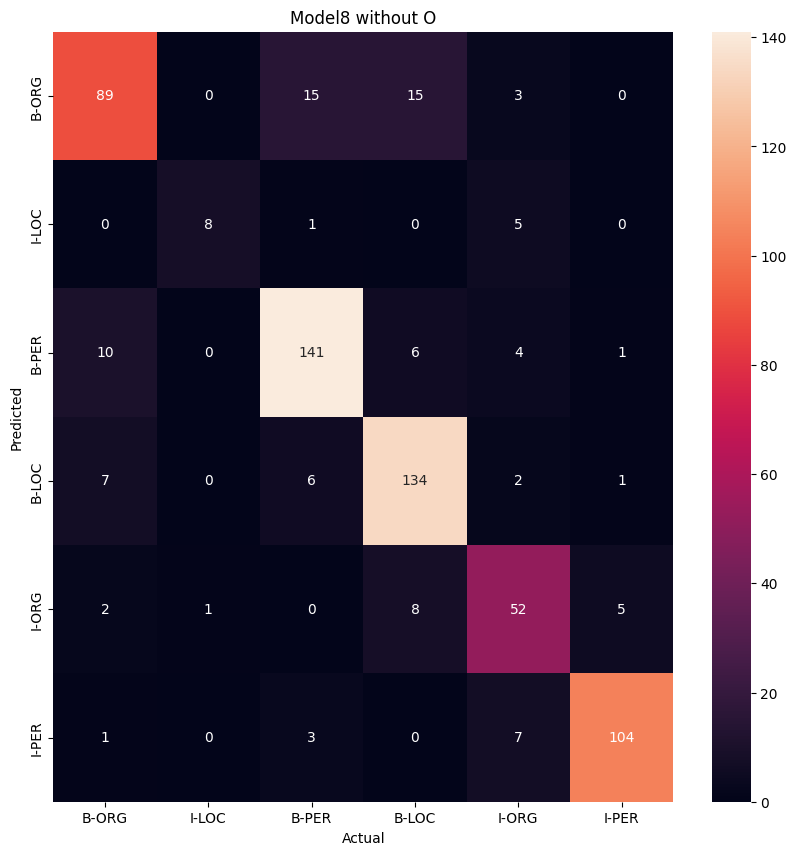

Epochs: 100%|██████████| 5/5 [01:04<00:00, 12.92s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.53      0.62      0.57       168
           O       0.95      0.93      0.94      3096
       B-LOC       0.72      0.69      0.71       183
       I-LOC       0.29      0.35      0.31        23
       B-PER       0.73      0.76      0.74       200
       I-PER       0.82      0.81      0.81       157
       I-ORG       0.41      0.53      0.46       116

    accuracy                           0.88      3943
   macro avg       0.63      0.67      0.65      3943
weighted avg       0.89      0.88      0.88      3943



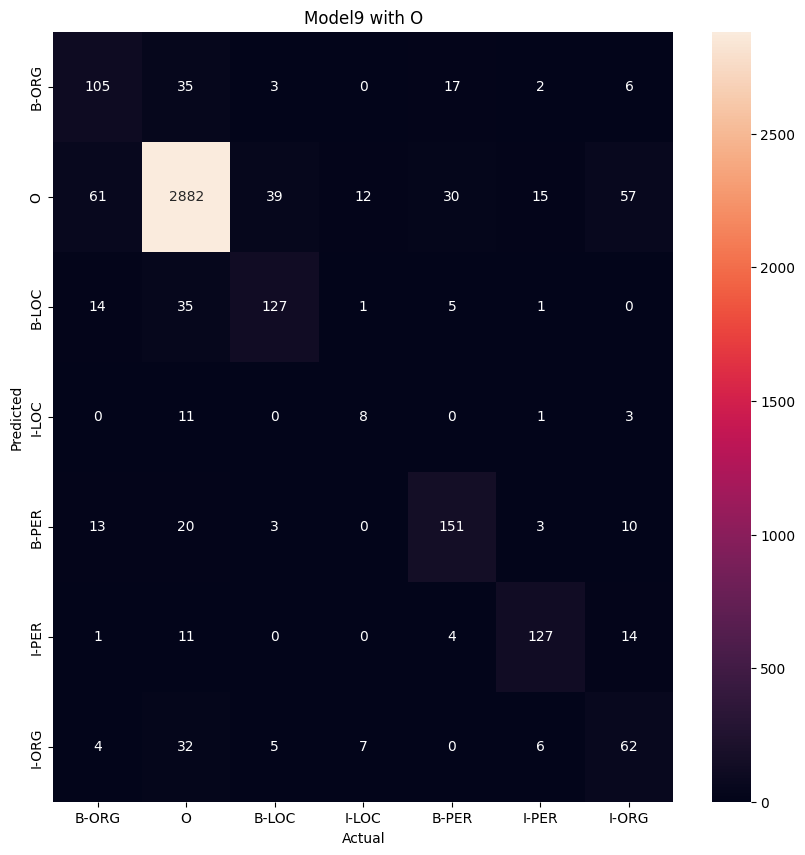

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.53      0.62      0.57       168
       I-LOC       0.29      0.35      0.31        23
       B-PER       0.73      0.76      0.74       200
       B-LOC       0.72      0.69      0.71       183
       I-ORG       0.41      0.53      0.46       116
       I-PER       0.82      0.81      0.81       157

   micro avg       0.63      0.68      0.66       847
   macro avg       0.58      0.63      0.60       847
weighted avg       0.65      0.68      0.66       847



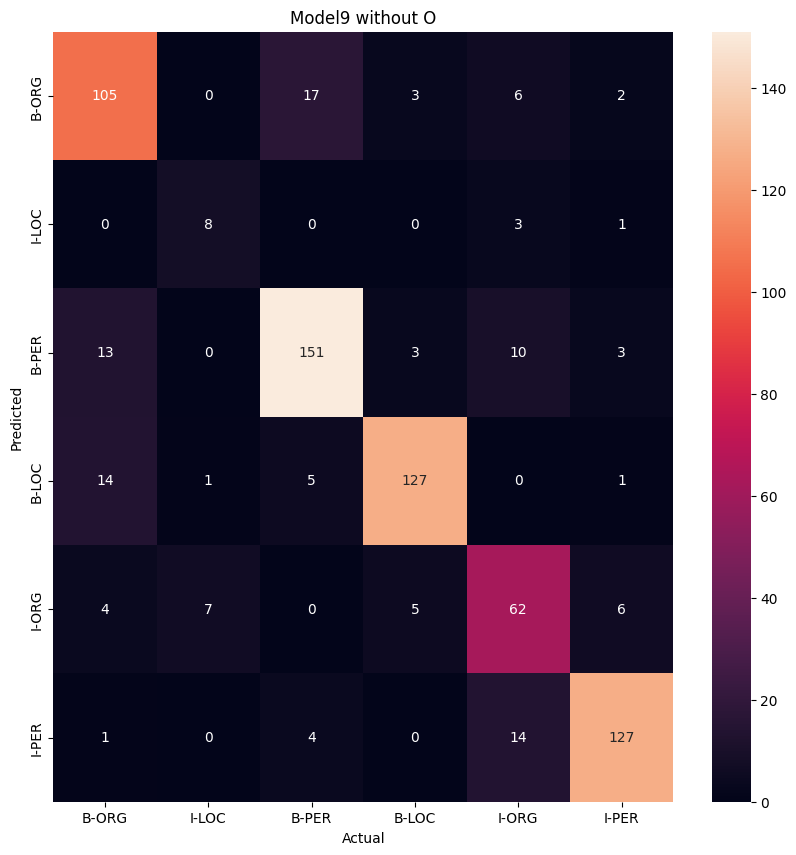

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PERCISION |     F1 |   RECALL_WO_O |   PERCISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | Model1    |           500 |          1 |            1 |   0.8156 |      0.7806 | 0.7599 |        0.7629 |           0.7641 |    0.7234 |
|  1 | Model2    |           500 |          2 |            1 |   0.8280 |      0.8081 | 0.7816 |        0.7695 |           0.7658 |    0.7454 |
|  2 | Model3    |           500 |          3 |            1 |   0.8209 |      0.7583 | 0.7831 |        0.6667 |           0.5477 |    0.5815 |
|  3 | Model4    |           500 |          1 |            2 |   0.8458 |      0.8069 | 0.8080 |        0.8050 |           0.7550 |    0

In [ ]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results.csv"
# TO DO ----------------------------------------------------------------------

for i, (model_name, hyperparameters) in enumerate(models.items()):
  model = NERNet(input_size=vocab.n_words, embedding_size=hyperparameters['embedding_size'],
                hidden_size=hyperparameters['hidden_size'],
                n_layers=hyperparameters['n_layers'],
                directions=hyperparameters['directions'],
                output_size=vocab.n_tags)

  metrics = train_loop(model, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
  result = evaluate(model, model_name, dl_dev, vocab)
  new_row = pd.DataFrame([{
        'N_MODEL': model_name,
        'N_LAYERS': hyperparameters['n_layers'],
        'HIDDEN_SIZE': hyperparameters['hidden_size'],
        'DIRECTIONS': hyperparameters['directions'],
        'RECALL': result['RECALL'],
        'PERCISION': result['PERCISION'],
        'F1': result['F1'],
        'RECALL_WO_O': result['RECALL_WO_O'],
        'PERCISION_WO_O': result['PERCISION_WO_O'],
        'F1_WO_O': result['F1_WO_O']
  }])
  results = pd.concat([results, new_row], ignore_index=True)

results.to_csv(file_name, index=False)
# TO DO ----------------------------------------------------------------------
print(tabulate(results, headers='keys', tablefmt='psql',floatfmt=".4f"))


## Step 4 - best model
Decide which model performs the best, write its configuration, train it for 5 more epochs and evaluate it on the test set.

In [ ]:
best_model_cfg = {'embedding_size':EMB_DIM, 'hidden_size': -1, 'n_layers': -1, 'directions': -1}
# TO DO ----------------------------------------------------------------------
best_model_cfg = {'embedding_size':EMB_DIM, 'hidden_size': models['Model6']['hidden_size'], 'n_layers': models['Model6']['n_layers'], 'directions': models['Model6']['directions']}
model = NERNet(input_size=vocab.n_words, embedding_size=best_model_cfg['embedding_size'],
                 hidden_size=best_model_cfg['hidden_size'],
                 n_layers=best_model_cfg['n_layers'],
                directions=best_model_cfg['directions'],
                 output_size=vocab.n_tags)
metrics = train_loop(model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
# TO DO ----------------------------------------------------------------------

Epochs: 100%|██████████| 10/10 [00:53<00:00,  5.34s/it]

Training completed.


<br><br><br><br><br>

# Part 4 - Pretrained Embeddings



To prepare for this task, please read [this discussion](https://discuss.pytorch.org/t/can-we-use-pre-trained-word-embeddings-for-weight-initialization-in-nn-embedding/1222).

**TIP**: Ensure that the vectors are aligned with the IDs in your vocabulary. In other words, make sure that the word with ID 0 corresponds to the first vector in the GloVe matrix used to initialize `nn.Embedding`.



## Step 1: Get Data



Download the GloVe embeddings from [this link](https://nlp.stanford.edu/projects/glove/). Use the 300-dimensional vectors from `glove.6B.zip`.



In [ ]:
# TO DO ----------------------------------------------------------------------
!wget --no-check-certificate 'https://nlp.stanford.edu/data/glove.6B.zip' -O glove6B.zip
!unzip  glove6B.zip
# TO DO ----------------------------------------------------------------------

--2025-06-21 19:52:46--  https://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-06-21 19:52:46--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
  Issued certificate has expired.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove6B.zip’

glove6B.zip         100%[===================>] 822.24M  5.00MB/s    in 2m 39s  

2025-06-21 19:55:25 (5.17 MB/s) - ‘glove6B.zip’ saved [862182613/862182613]

Archive:  glove6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glov

## Step 2: Inject Embeddings

Then intialize the `nn.Embedding` module in your `NERNet` with these embeddings, so that you can start your training with pre-trained vectors.

In [ ]:
def get_emb_matrix(filepath: str, vocab: Vocab) -> np.ndarray:
  emb_matrix = np.zeros((len(vocab.word2id), 300))
  # TO DO ----------------------------------------------------------------------
  # # load GloVe embeddings
  # glove_file_path = 'data/glove.6B.300d.txt'
  # glove_embeddings = load_glove_embeddings(glove_file_path)

  # # put values in the embedding matrix
  # for word, idx in vocab.word2id.items():
  #     # if a word have embedding
  #     if word in glove_embeddings:
  #         emb_matrix[idx] = glove_embeddings[word]
  #     # in case a word to not have emmbeding - init with random to avoid OOV
  #     else:
  #         emb_matrix[idx] = np.random.normal(scale=0.6, size=(300,))
  emb_matrix = np.zeros((len(vocab.word2id), 300))
  with open(filepath, 'r', encoding='utf-8') as file:
    for line in file:
      line = line.strip().split()
      word = line[0]
      if word in vocab.word2id:
        emb_matrix[vocab.word2id[word]] = np.array(line[1:], dtype=np.float32)
  # TO DO ----------------------------------------------------------------------
  return emb_matrix

In [ ]:
def initialize_from_pretrained_emb(model: NERNet, emb_matrix: np.ndarray):
  """
  Inject the pretrained embeddings into the model.
  :param model: model instance
  :param emb_matrix: pretrained embeddings
  """
  # TO DO ----------------------------------------------------------------------
  model.embedding.weight.data.copy_(th.tensor(emb_matrix))
  # TO DO ----------------------------------------------------------------------

In [ ]:
# Read embeddings and inject them to a model
emb_file = 'glove.6B.300d.txt'
emb_matrix = get_emb_matrix(emb_file, vocab)
ner_glove = NERNet(input_size=vocab.n_words, embedding_size=EMB_DIM, hidden_size=500, output_size=vocab.n_tags, n_layers=1, directions=1)
initialize_from_pretrained_emb(ner_glove, emb_matrix)

## Step 3: Evaluate on Test Set

Same as the evaluation process before, please display:

1. Print a `RECALL-PERCISION-F1` scores in a tabulate format.
2. Display a `confusion matrix` plot: where the predicted labels are the rows, and the true labels are the columns.

Make sure to use the title for the plot, axis names, and the names of the tags on the X-axis.

Make sure to download and upload this CSV as well.

Training Model1...


Epochs: 100%|██████████| 5/5 [00:04<00:00,  1.03it/s]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.91      0.06      0.11       168
           O       0.88      0.97      0.92      3096
       B-LOC       0.61      0.47      0.53       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.53      0.39      0.45       200
       I-PER       0.44      0.59      0.51       157
       I-ORG       0.47      0.08      0.13       116

    accuracy                           0.83      3943
   macro avg       0.55      0.37      0.38      3943
weighted avg       0.82      0.83      0.80      3943



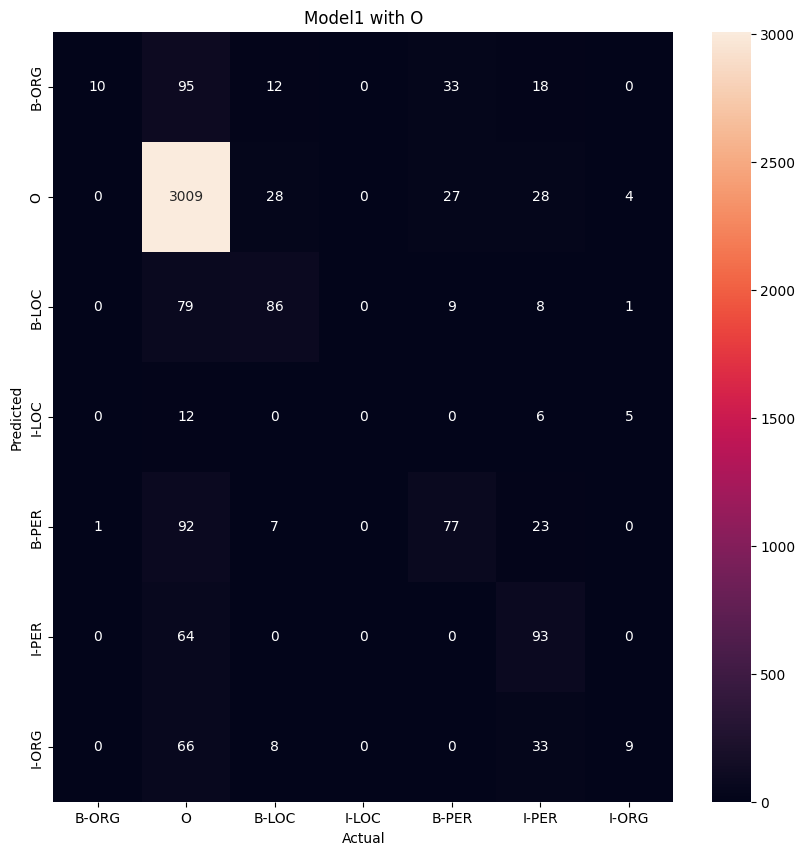

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.91      0.06      0.11       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.53      0.39      0.45       200
       B-LOC       0.61      0.47      0.53       183
       I-ORG       0.47      0.08      0.13       116
       I-PER       0.44      0.59      0.51       157

   micro avg       0.52      0.32      0.40       847
   macro avg       0.49      0.26      0.29       847
weighted avg       0.58      0.32      0.35       847



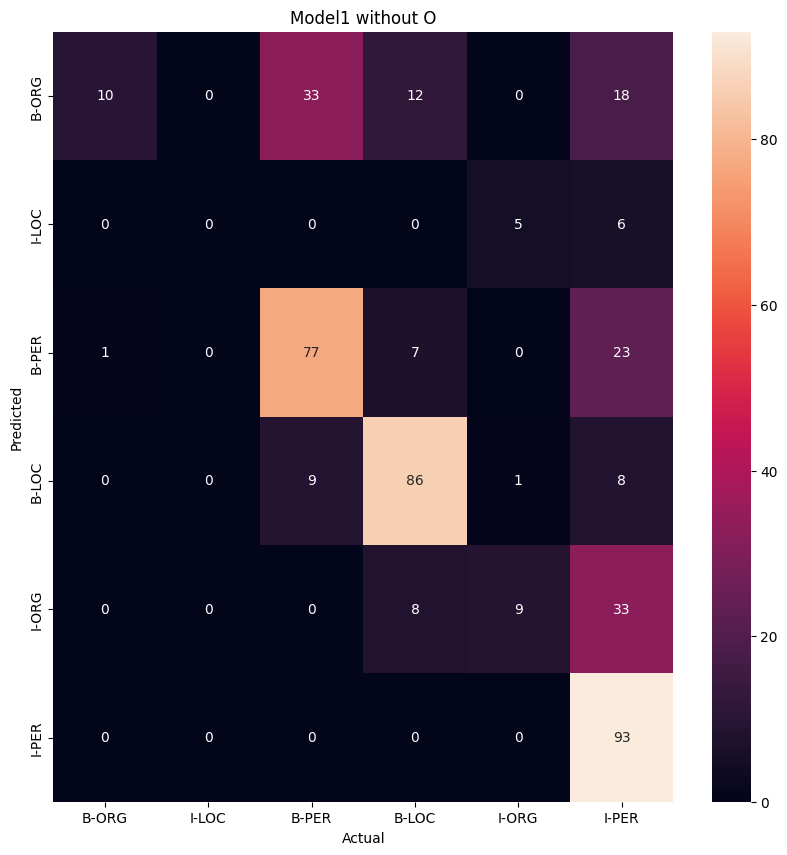

/tmp/ipython-input-30-15876350.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


Training Model2...


Epochs: 100%|██████████| 5/5 [00:08<00:00,  1.70s/it]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Training completed.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.53      0.05      0.09       168
           O       0.88      0.98      0.93      3096
       B-LOC       0.58      0.56      0.57       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.66      0.41      0.51       200
       I-PER       0.57      0.55      0.56       157
       I-ORG       0.39      0.16      0.23       116

    accuracy                           0.84      3943
   macro avg       0.52      0.39      0.41      3943
weighted avg       0.81      0.84      0.81      3943



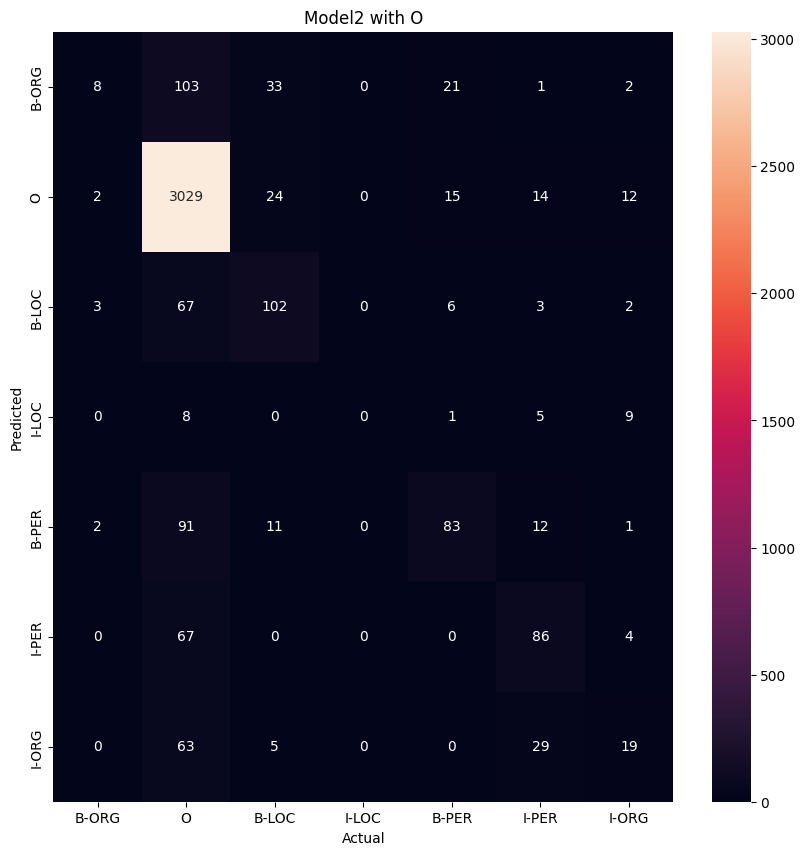

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.53      0.05      0.09       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.66      0.41      0.51       200
       B-LOC       0.58      0.56      0.57       183
       I-ORG       0.39      0.16      0.23       116
       I-PER       0.57      0.55      0.56       157

   micro avg       0.58      0.35      0.44       847
   macro avg       0.46      0.29      0.33       847
weighted avg       0.55      0.35      0.40       847



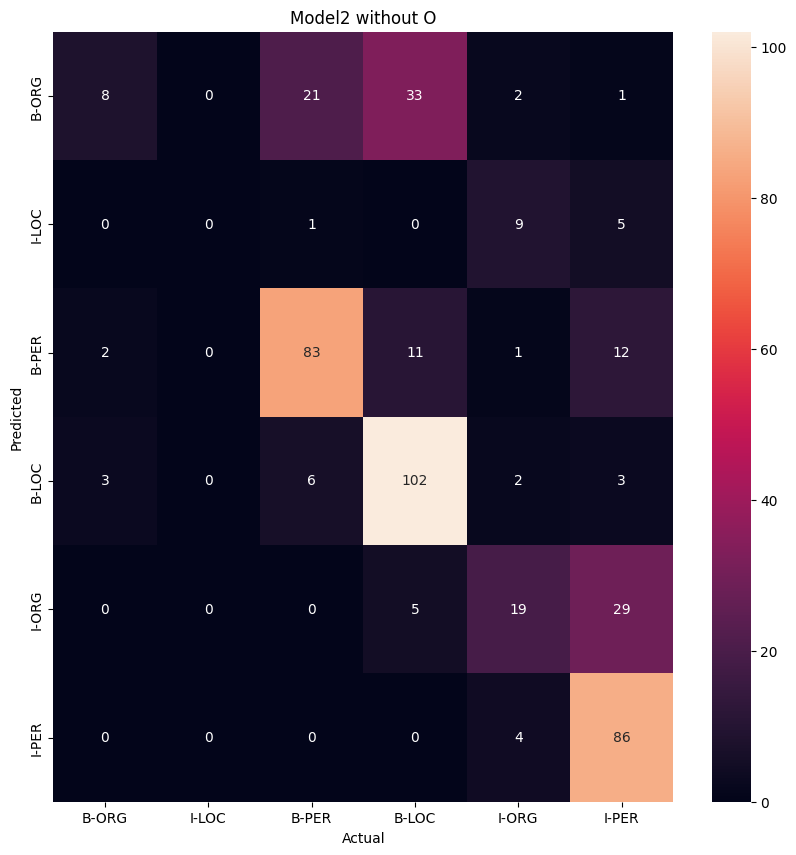

Training Model3...


Epochs: 100%|██████████| 5/5 [00:11<00:00,  2.38s/it]


Training completed.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.00      0.00      0.00       168
           O       0.89      0.97      0.93      3096
       B-LOC       0.43      0.62      0.50       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.71      0.30      0.43       200
       I-PER       0.76      0.56      0.64       157
       I-ORG       0.31      0.22      0.26       116

    accuracy                           0.84      3943
   macro avg       0.44      0.38      0.40      3943
weighted avg       0.79      0.84      0.81      3943



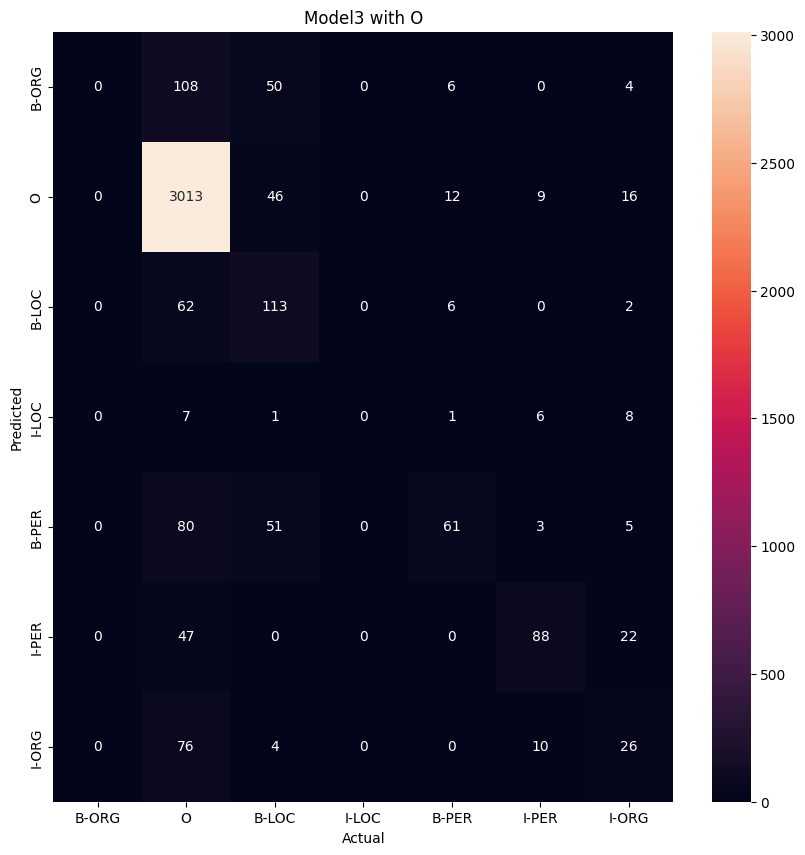

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.00      0.00      0.00       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.71      0.30      0.43       200
       B-LOC       0.43      0.62      0.50       183
       I-ORG       0.31      0.22      0.26       116
       I-PER       0.76      0.56      0.64       157

   micro avg       0.52      0.34      0.41       847
   macro avg       0.37      0.28      0.31       847
weighted avg       0.44      0.34      0.37       847



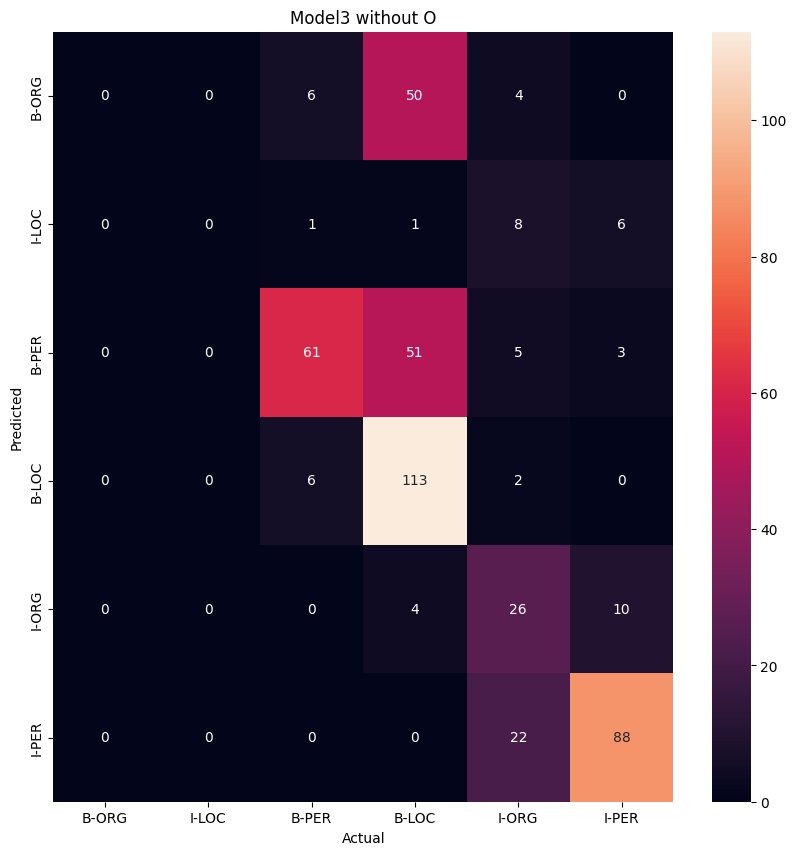

Training Model4...


Epochs: 100%|██████████| 5/5 [00:07<00:00,  1.56s/it]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

Training completed.


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.67      0.34      0.45       168
           O       0.92      0.98      0.95      3096
       B-LOC       0.63      0.57      0.60       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.74      0.67      0.70       200
       I-PER       0.70      0.71      0.70       157
       I-ORG       0.50      0.15      0.23       116

    accuracy                           0.88      3943
   macro avg       0.59      0.49      0.52      3943
weighted avg       0.86      0.88      0.86      3943



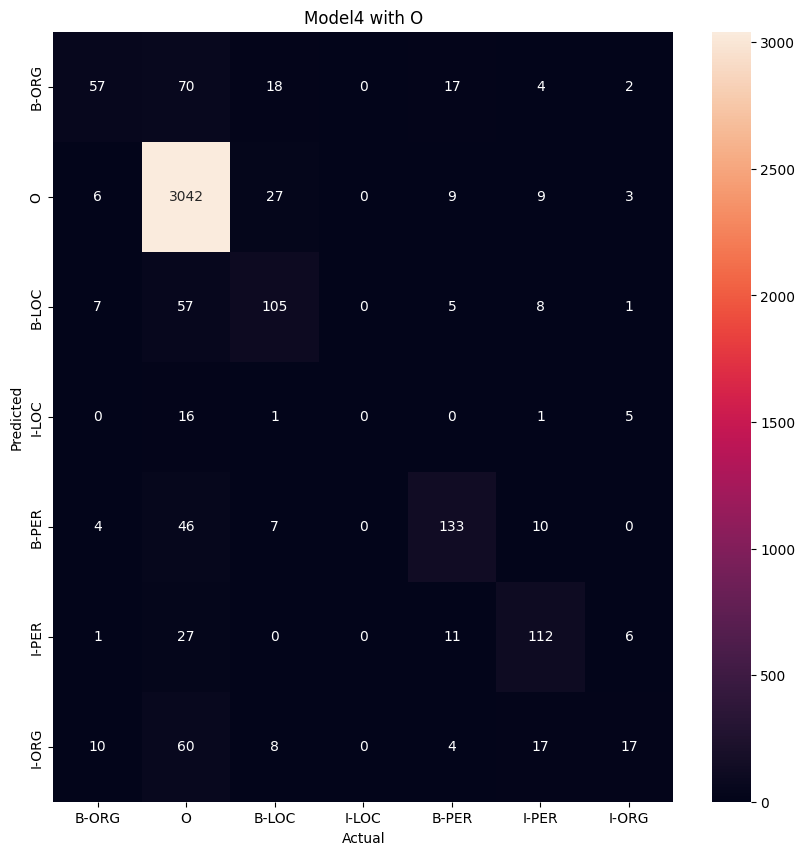

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.67      0.34      0.45       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.74      0.67      0.70       200
       B-LOC       0.63      0.57      0.60       183
       I-ORG       0.50      0.15      0.23       116
       I-PER       0.70      0.71      0.70       157

   micro avg       0.68      0.50      0.58       847
   macro avg       0.54      0.41      0.45       847
weighted avg       0.64      0.50      0.55       847



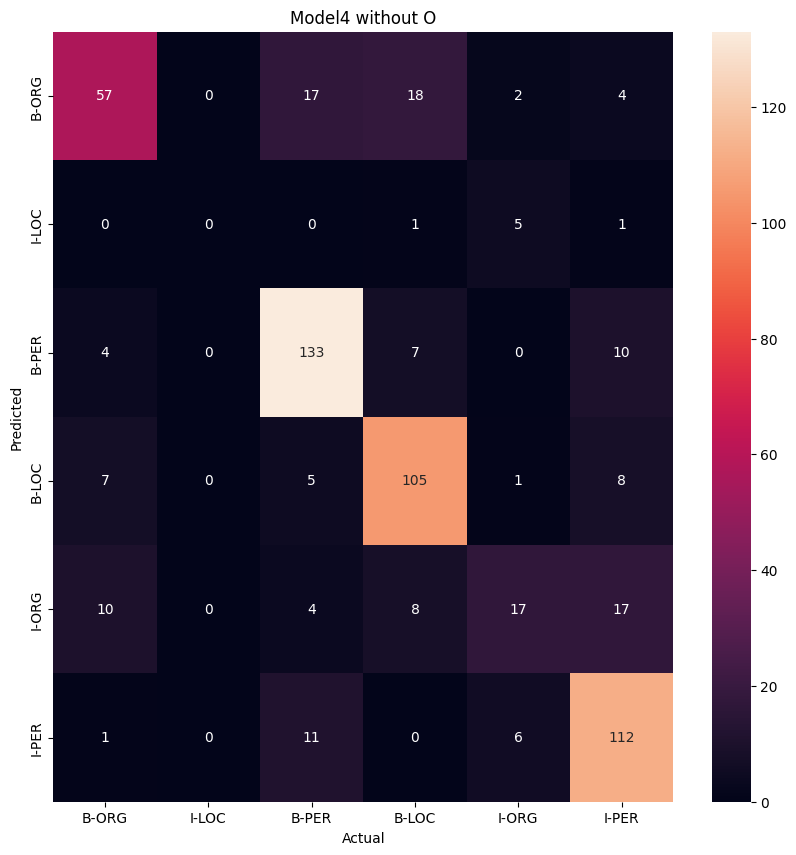

Training Model5...


Epochs: 100%|██████████| 5/5 [00:17<00:00,  3.48s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.56      0.48      0.52       168
           O       0.97      0.95      0.96      3096
       B-LOC       0.55      0.76      0.63       183
       I-LOC       0.50      0.04      0.08        23
       B-PER       0.73      0.81      0.77       200
       I-PER       0.77      0.89      0.82       157
       I-ORG       0.51      0.45      0.48       116

    accuracy                           0.89      3943
   macro avg       0.66      0.62      0.61      3943
weighted avg       0.89      0.89      0.89      3943



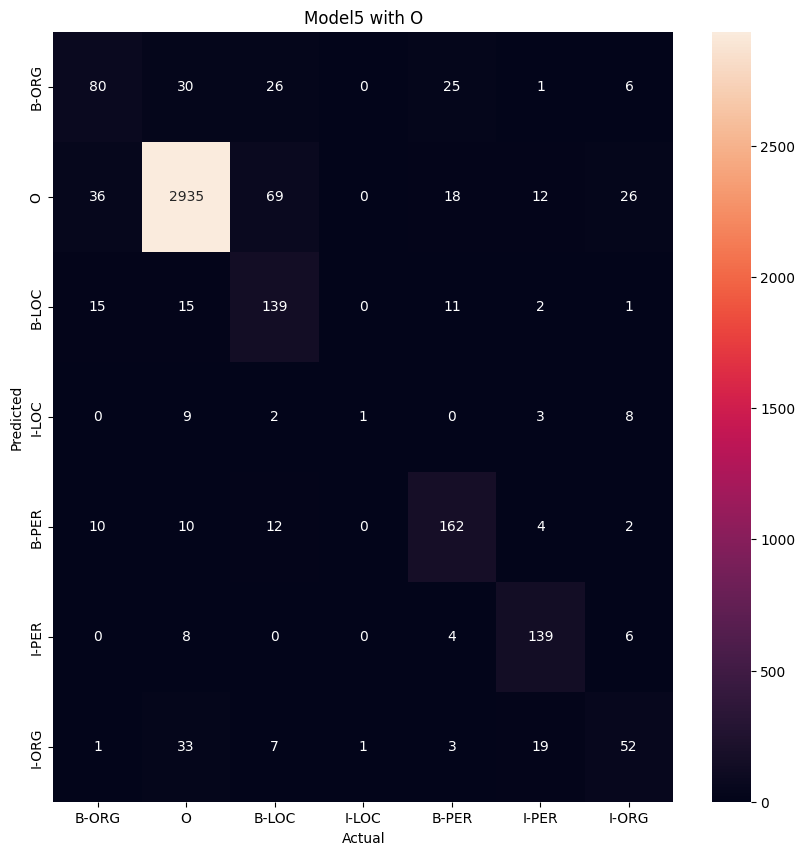

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.56      0.48      0.52       168
       I-LOC       0.50      0.04      0.08        23
       B-PER       0.73      0.81      0.77       200
       B-LOC       0.55      0.76      0.63       183
       I-ORG       0.51      0.45      0.48       116
       I-PER       0.77      0.89      0.82       157

   micro avg       0.63      0.68      0.65       847
   macro avg       0.60      0.57      0.55       847
weighted avg       0.63      0.68      0.64       847



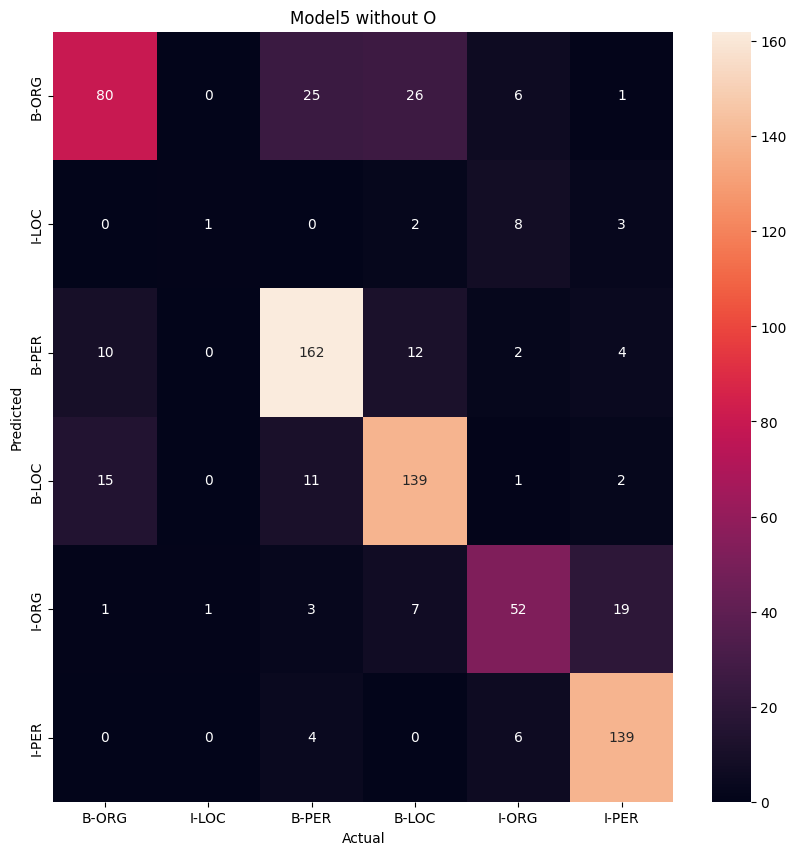

Training Model6...


Epochs: 100%|██████████| 5/5 [00:26<00:00,  5.31s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.55      0.54      0.54       168
           O       0.97      0.94      0.95      3096
       B-LOC       0.46      0.74      0.57       183
       I-LOC       0.17      0.04      0.07        23
       B-PER       0.72      0.81      0.76       200
       I-PER       0.78      0.92      0.84       157
       I-ORG       0.65      0.47      0.54       116

    accuracy                           0.88      3943
   macro avg       0.61      0.64      0.61      3943
weighted avg       0.90      0.88      0.89      3943



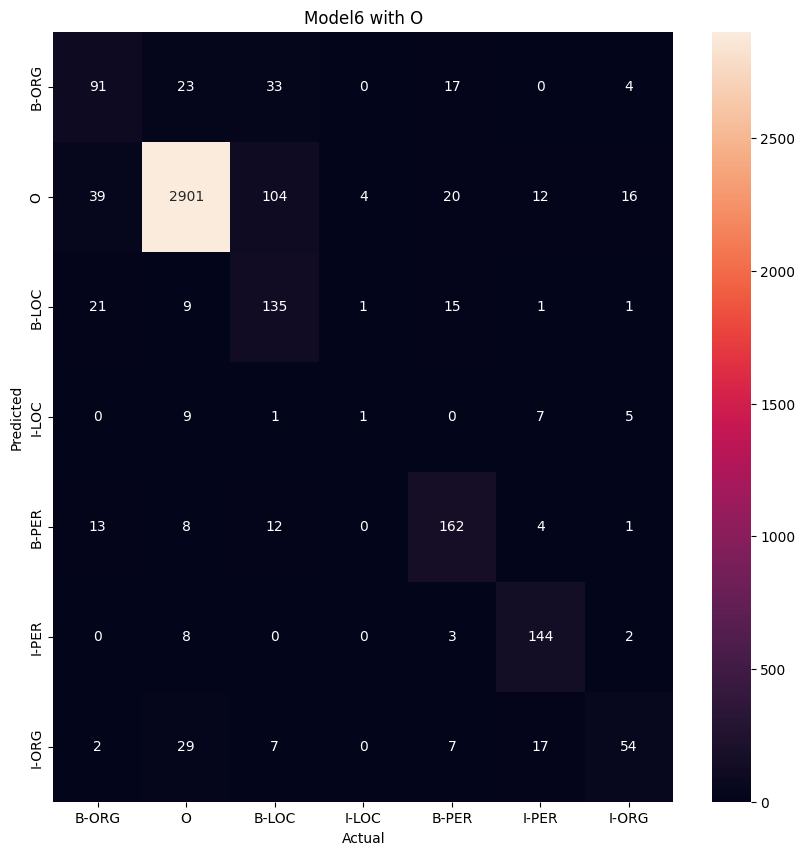

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.55      0.54      0.54       168
       I-LOC       0.17      0.04      0.07        23
       B-PER       0.72      0.81      0.76       200
       B-LOC       0.46      0.74      0.57       183
       I-ORG       0.65      0.47      0.54       116
       I-PER       0.78      0.92      0.84       157

   micro avg       0.61      0.69      0.65       847
   macro avg       0.55      0.59      0.56       847
weighted avg       0.62      0.69      0.64       847



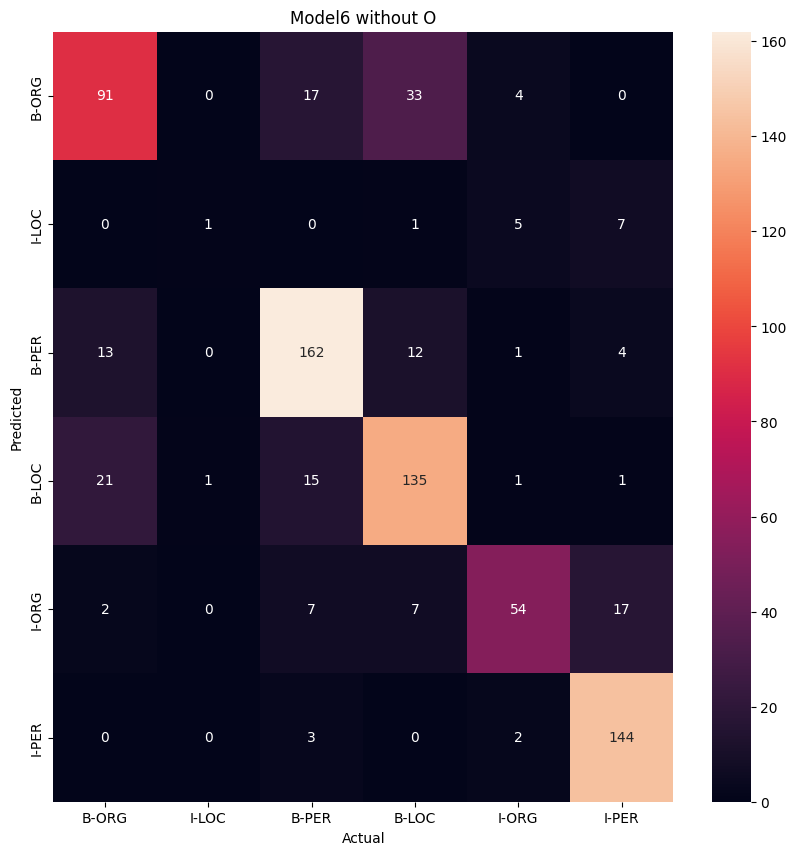

Training Model7...


Epochs: 100%|██████████| 5/5 [00:15<00:00,  3.20s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.78      0.29      0.42       168
           O       0.92      0.99      0.95      3096
       B-LOC       0.75      0.42      0.53       183
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.62      0.77      0.69       200
       I-PER       0.66      0.78      0.72       157
       I-ORG       0.62      0.07      0.12       116

    accuracy                           0.88      3943
   macro avg       0.62      0.47      0.49      3943
weighted avg       0.86      0.88      0.86      3943



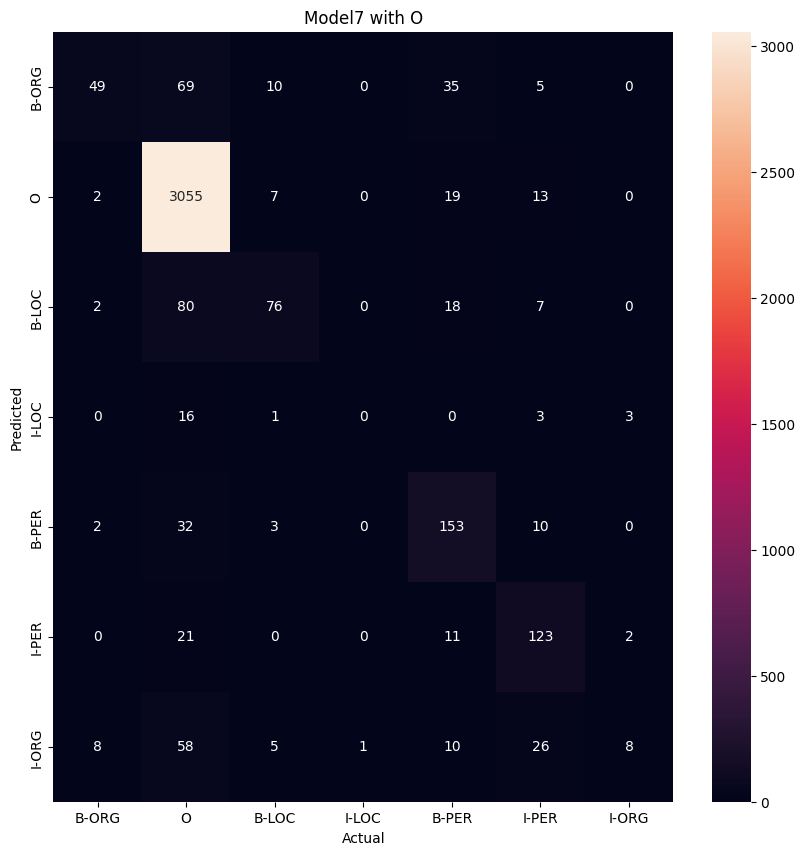

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.78      0.29      0.42       168
       I-LOC       0.00      0.00      0.00        23
       B-PER       0.62      0.77      0.69       200
       B-LOC       0.75      0.42      0.53       183
       I-ORG       0.62      0.07      0.12       116
       I-PER       0.66      0.78      0.72       157

   micro avg       0.67      0.48      0.56       847
   macro avg       0.57      0.39      0.41       847
weighted avg       0.67      0.48      0.51       847



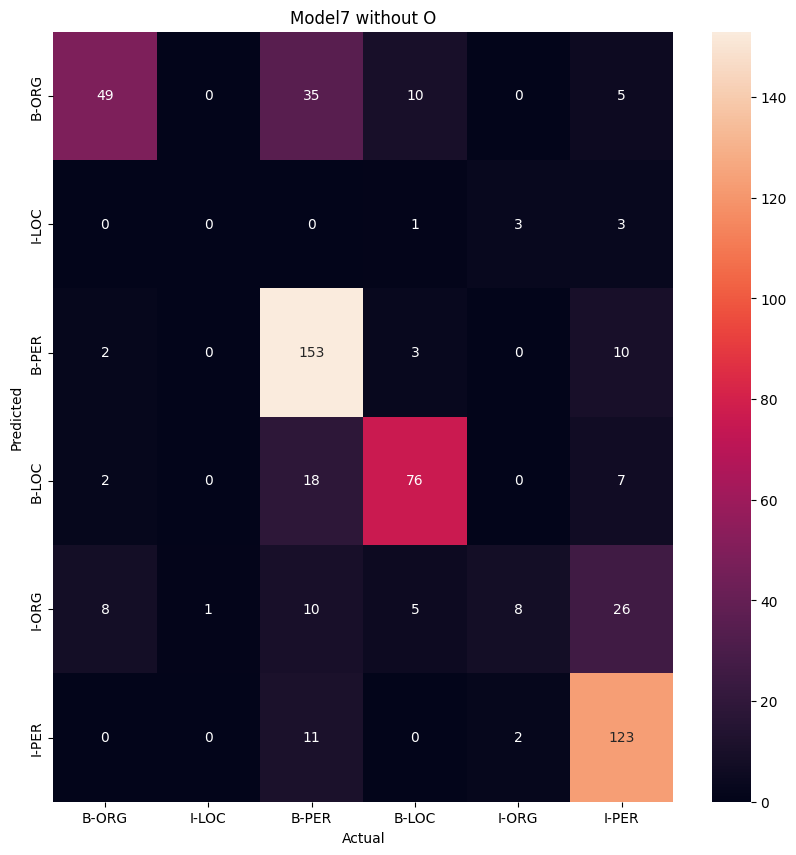

Training Model8...


Epochs: 100%|██████████| 5/5 [00:40<00:00,  8.07s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.53      0.54      0.54       168
           O       0.98      0.93      0.95      3096
       B-LOC       0.53      0.75      0.62       183
       I-LOC       0.67      0.17      0.28        23
       B-PER       0.71      0.81      0.76       200
       I-PER       0.76      0.90      0.83       157
       I-ORG       0.46      0.61      0.53       116

    accuracy                           0.88      3943
   macro avg       0.66      0.68      0.64      3943
weighted avg       0.90      0.88      0.89      3943



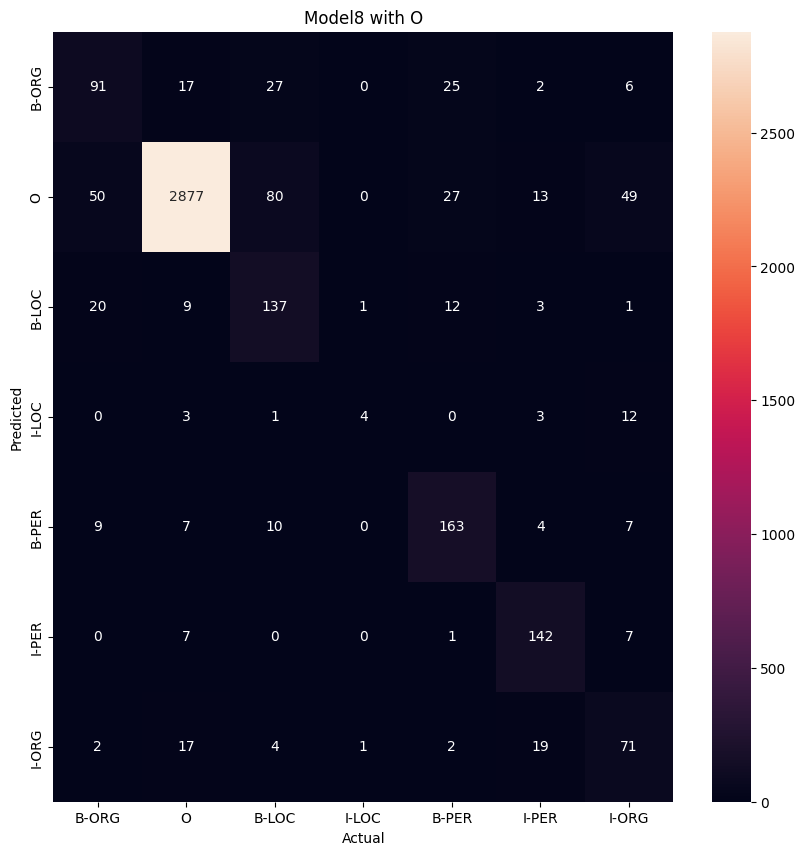

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.53      0.54      0.54       168
       I-LOC       0.67      0.17      0.28        23
       B-PER       0.71      0.81      0.76       200
       B-LOC       0.53      0.75      0.62       183
       I-ORG       0.46      0.61      0.53       116
       I-PER       0.76      0.90      0.83       157

   micro avg       0.60      0.72      0.66       847
   macro avg       0.61      0.63      0.59       847
weighted avg       0.61      0.72      0.65       847



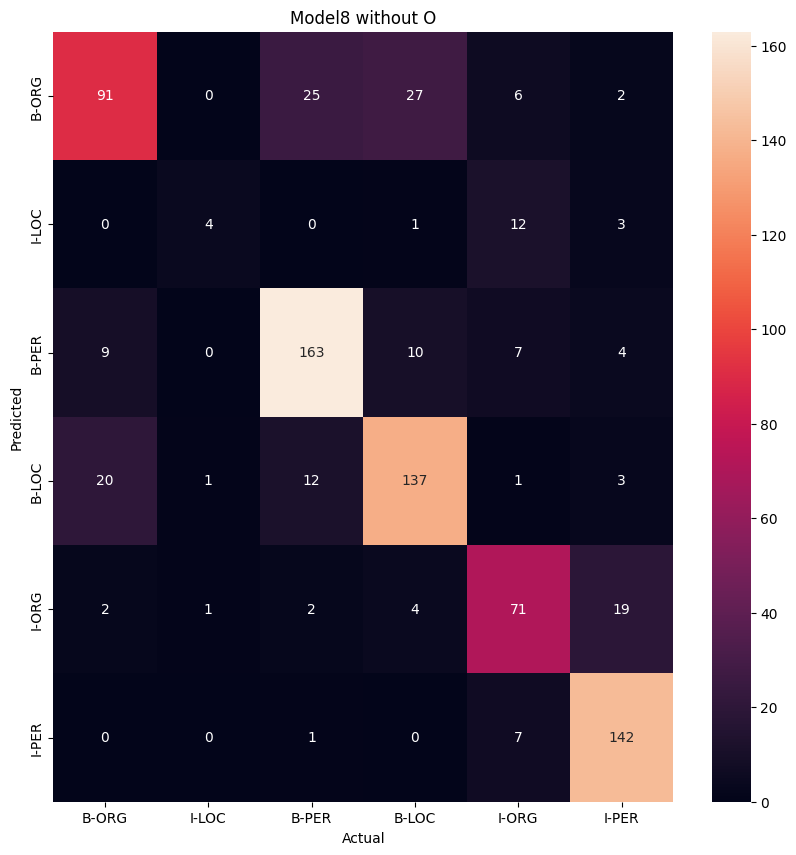

Training Model9...


Epochs: 100%|██████████| 5/5 [01:04<00:00, 12.94s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.52      0.64      0.58       168
           O       0.98      0.95      0.96      3096
       B-LOC       0.58      0.78      0.67       183
       I-LOC       0.14      0.04      0.07        23
       B-PER       0.82      0.69      0.75       200
       I-PER       0.86      0.85      0.85       157
       I-ORG       0.52      0.62      0.57       116

    accuracy                           0.90      3943
   macro avg       0.63      0.65      0.63      3943
weighted avg       0.91      0.90      0.90      3943



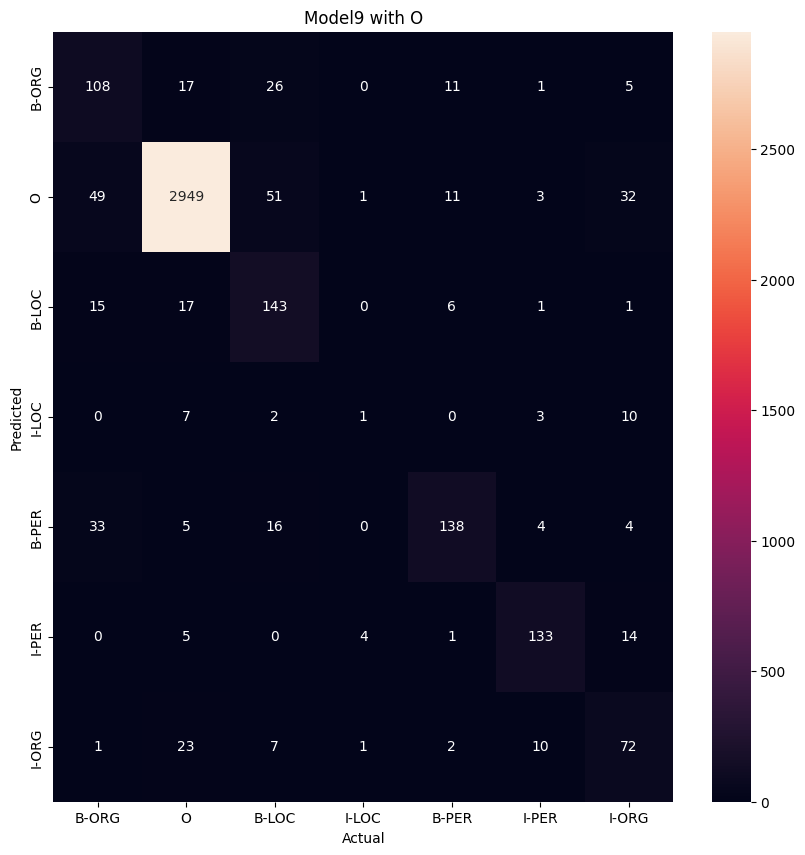

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.52      0.64      0.58       168
       I-LOC       0.14      0.04      0.07        23
       B-PER       0.82      0.69      0.75       200
       B-LOC       0.58      0.78      0.67       183
       I-ORG       0.52      0.62      0.57       116
       I-PER       0.86      0.85      0.85       157

   micro avg       0.65      0.70      0.67       847
   macro avg       0.57      0.60      0.58       847
weighted avg       0.66      0.70      0.67       847



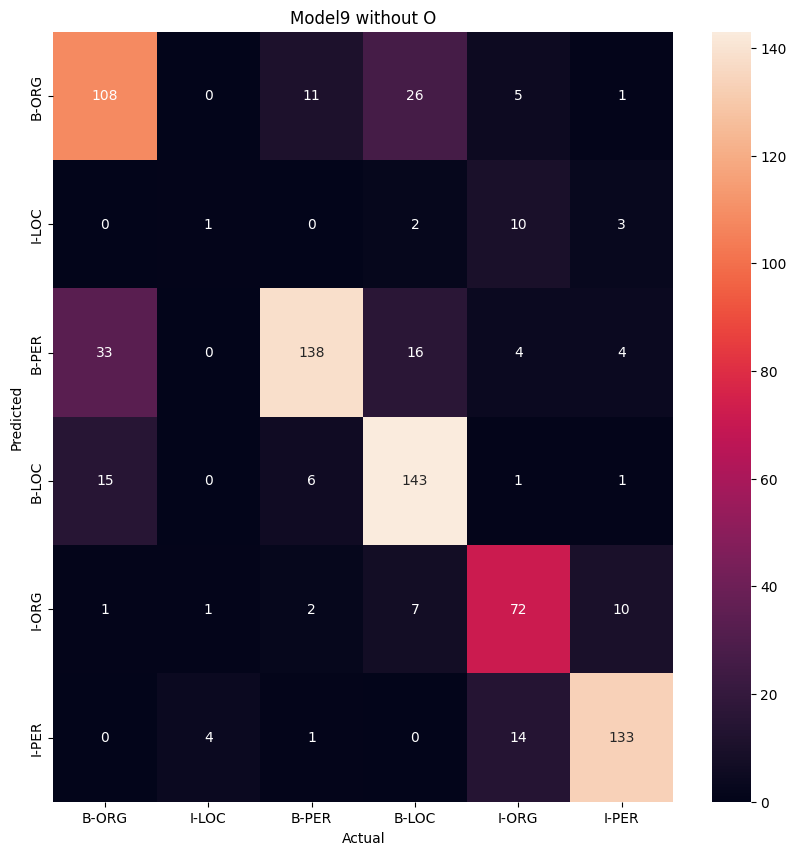

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PERCISION |     F1 |   RECALL_WO_O |   PERCISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | Model1    |           500 |          1 |            1 |   0.8329 |      0.8169 | 0.8016 |        0.6264 |           0.6678 |    0.5696 |
|  1 | Model2    |           500 |          2 |            1 |   0.8438 |      0.8112 | 0.8142 |        0.6652 |           0.6339 |    0.6140 |
|  2 | Model3    |           500 |          3 |            1 |   0.8372 |      0.7924 | 0.8076 |        0.6167 |           0.5725 |    0.5665 |
|  3 | Model4    |           500 |          1 |            2 |   0.8790 |      0.8579 | 0.8622 |        0.7426 |           0.7231 |    0

In [ ]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results_glove.csv"
# TO DO ----------------------------------------------------------------------
for i, (model_name, hyperparameters) in enumerate(models.items()):
  model = NERNet(input_size=vocab.n_words, embedding_size=hyperparameters['embedding_size'],
                hidden_size=hyperparameters['hidden_size'],
                n_layers=hyperparameters['n_layers'],
                directions=hyperparameters['directions'],
                output_size=vocab.n_tags)
  print(f"Training {model_name}...")
  initialize_from_pretrained_emb(model, emb_matrix)
  metrics = train_loop(model, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
  result = evaluate(model, model_name, dl_dev, vocab)
  new_row = pd.DataFrame([{
        'N_MODEL': model_name,
        'N_LAYERS': hyperparameters['n_layers'],
        'HIDDEN_SIZE': hyperparameters['hidden_size'],
        'DIRECTIONS': hyperparameters['directions'],
        'RECALL': result['RECALL'],
        'PERCISION': result['PERCISION'],
        'F1': result['F1'],
        'RECALL_WO_O': result['RECALL_WO_O'],
        'PERCISION_WO_O': result['PERCISION_WO_O'],
        'F1_WO_O': result['F1_WO_O']
  }])
  results = pd.concat([results, new_row], ignore_index=True)

results.to_csv(file_name, index=False)
# TO DO ----------------------------------------------------------------------
print(tabulate(results, headers='keys', tablefmt='psql',floatfmt=".4f"))

## Step 4 - best model
Decide which model performs the best, write its configuration, train it for 5 more epochs and evaluate it on the test set.

Epochs: 100%|██████████| 10/10 [00:53<00:00,  5.35s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.71      0.60      0.65       350
           O       0.94      0.98      0.96      6567
       B-LOC       0.82      0.73      0.77       343
       I-LOC       0.90      0.49      0.63        53
       B-PER       0.80      0.73      0.76       434
       I-PER       0.88      0.71      0.78       296
       I-ORG       0.79      0.36      0.49       200

    accuracy                           0.91      8243
   macro avg       0.83      0.66      0.72      8243
weighted avg       0.91      0.91      0.91      8243



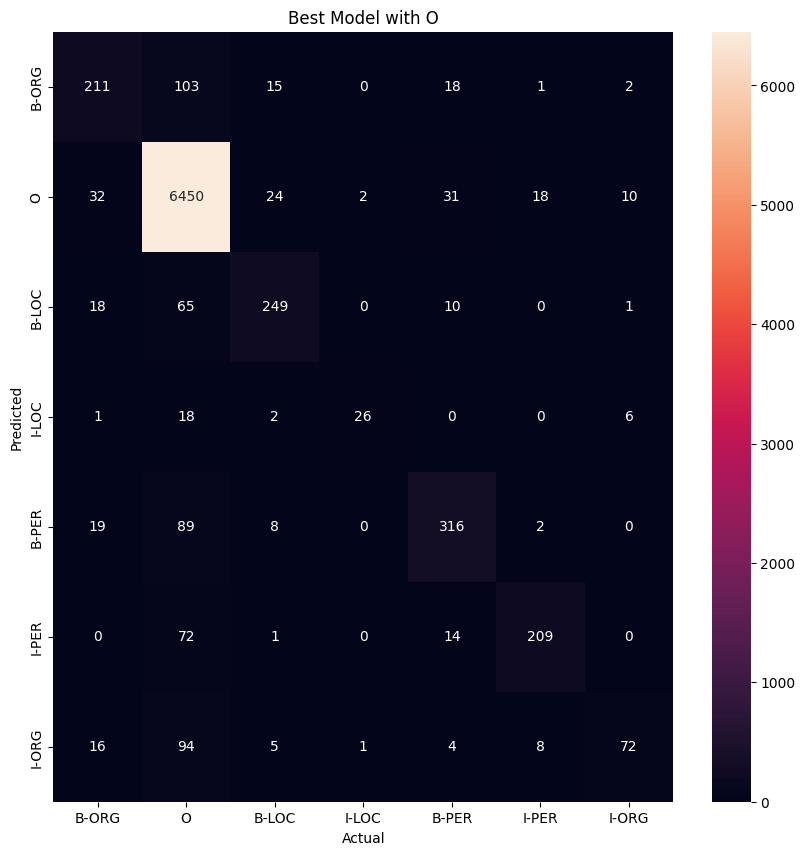

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.71      0.60      0.65       350
       I-LOC       0.90      0.49      0.63        53
       B-PER       0.80      0.73      0.76       434
       B-LOC       0.82      0.73      0.77       343
       I-ORG       0.79      0.36      0.49       200
       I-PER       0.88      0.71      0.78       296

   micro avg       0.80      0.65      0.72      1676
   macro avg       0.82      0.60      0.68      1676
weighted avg       0.80      0.65      0.71      1676



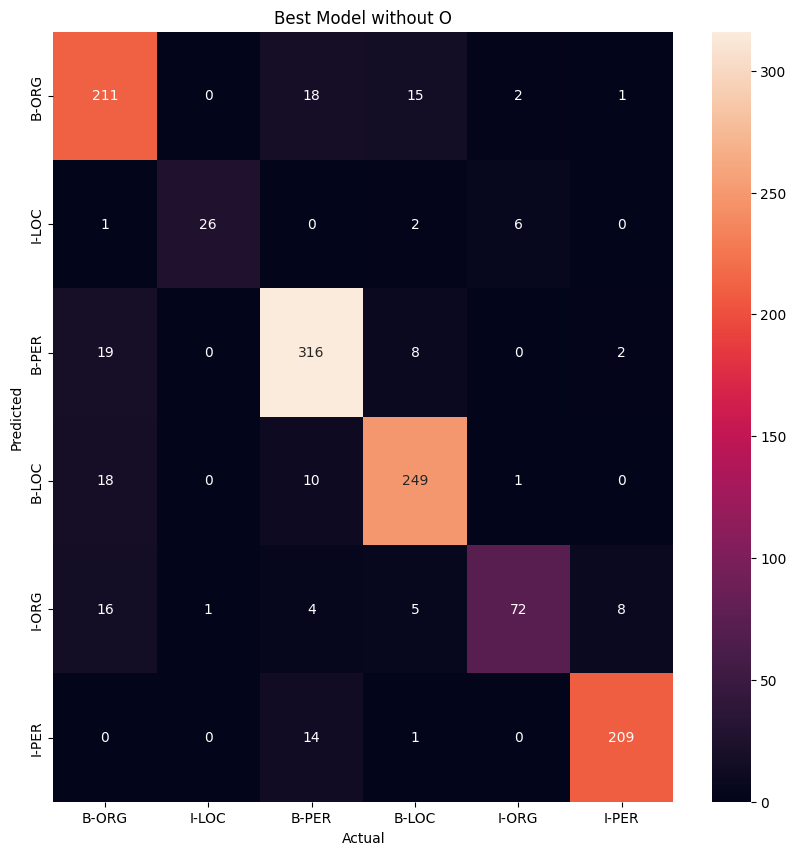

{'PERCISION': 0.9087699676115598, 'RECALL': 0.9138663108091715, 'F1': 0.9077952233981483, 'PERCISION_WO_O': 0.8791704453604303, 'RECALL_WO_O': 0.8769230769230769, 'F1_WO_O': 0.8760766360211069}


In [ ]:
best_model_glove_cfg = {'embedding_size':EMB_DIM, 'hidden_size': -1, 'n_layers': -1, 'directions': -1}
# TO DO ----------------------------------------------------------------------
best_model_glove_cfg = {'embedding_size':EMB_DIM, 'hidden_size': models['Model9']['hidden_size'], 'n_layers': models['Model9']['n_layers'], 'directions': models['Model9']['directions']}
model = NERNet(input_size=vocab.n_words, embedding_size=best_model_cfg['embedding_size'],
                 hidden_size=best_model_cfg['hidden_size'],
                 n_layers=best_model_cfg['n_layers'],
                directions=best_model_cfg['directions'],
                 output_size=vocab.n_tags)
metrics = train_loop(model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
results = evaluate(model, 'Best Model', dl_test, vocab)
print(results)
# TO DO ----------------------------------------------------------------------

# Part 5 - Error Analysis

In this part, you'll analyze the errors made by your best model to understand its strengths and weaknesses.

## Step 1: Extract Predictions

First, let's extract predictions from your best model on the test set:

In [ ]:
def get_predictions(model, dataloader, vocab, PAD_TOKEN, DEVICE):
    """
    Get predictions from the model on a dataloader.

    Returns:
        - true_tags_list: List of lists of true tag strings
        - pred_tags_list: List of lists of predicted tag strings
        - words_list: List of lists of words
    """
    import torch

    model.eval()
    true_tags_list = []
    pred_tags_list = []
    words_list = []

    with torch.no_grad():
        # Handle different dataloader output formats
        for batch in dataloader:
            # Unpack based on actual dataloader output
            if len(batch) == 3:  # (input_ids, casing_features, labels)
                input_ids, casing_features, labels = batch
                # Move tensors to device
                input_ids = input_ids.to(DEVICE)
                casing_features = casing_features.to(DEVICE)
                labels = labels.to(DEVICE)

                # Get model predictions
                outputs = model(input_ids, casing_features)
            else:  # (input_ids, labels)
                input_ids, labels = batch
                # Move tensors to device
                input_ids = input_ids.to(DEVICE)
                labels = labels.to(DEVICE)

                # Get model predictions
                outputs = model(input_ids)

            _, predicted = torch.max(outputs, 2)

            # Process each sequence in the batch
            for i in range(input_ids.size(0)):
                # Get sequence length (ignoring padding)
                seq_len = (input_ids[i] != PAD_TOKEN).sum().item()

                # Convert ids to tag strings and words
                true_tags = [vocab.id2tag[tag.item()] for tag in labels[i][:seq_len]]
                pred_tags = [vocab.id2tag[tag.item()] for tag in predicted[i][:seq_len]]
                words = [vocab.id2word[word.item()] for word in input_ids[i][:seq_len]]

                true_tags_list.append(true_tags)
                pred_tags_list.append(pred_tags)
                words_list.append(words)

    return true_tags_list, pred_tags_list, words_list

## Step 2: Implement Simple Error Analysis

Now, implement a function to analyze the errors in predictions:

In [ ]:
def simple_analyze_errors(true_tags, pred_tags, words):
    """
    Analyze errors in NER predictions.

    Args:
        true_tags: List of true tag sequences
        pred_tags: List of predicted tag sequences
        words: List of word sequences

    Returns:
        dict: Error statistics and examples
    """
     # 1. Initialize error categories and counters
    error_counts = {}
    error_examples = {}
    total_tokens = 0
    correct_tokens = 0
    total_entities = 0
    correct_entities = 0 # This will be tricky to count perfectly without entity-level metrics

    # 2. Process each sequence to identify errors
    for i in range(len(true_tags)):
        true_sentence_tags = true_tags[i]
        pred_sentence_tags = pred_tags[i]
        sentence_words = words[i]

        # Iterate through tokens in the sentence
        for j in range(len(true_sentence_tags)):
            total_tokens += 1
            true_tag = true_sentence_tags[j]
            pred_tag = pred_sentence_tags[j]
            word = sentence_words[j]

            if true_tag == pred_tag:
                correct_tokens += 1
            else:
                # 3. Categorize errors and collect examples
                error_type = f"True: {true_tag}, Pred: {pred_tag}"

                # Count errors
                error_counts[error_type] = error_counts.get(error_type, 0) + 1

                # Collect examples (store the sentence context)
                if error_type not in error_examples:
                    error_examples[error_type] = []

                # Store the word causing the error and its context (e.g., the whole sentence)
                if len(error_examples[error_type]) < 5: # Limit examples to avoid excessive output
                     error_examples[error_type].append({
                         'word': word,
                         'sentence': ' '.join(sentence_words),
                         'true_tags': ' '.join(true_sentence_tags),
                         'pred_tags': ' '.join(pred_sentence_tags)
                     })

            # A very simple way to count total entities (might overcount with IOB)
            if true_tag != 'O':
                total_entities += 1

    # Calculate token-level accuracy
    token_accuracy = correct_tokens / total_tokens if total_tokens > 0 else 0.0

    # Note: Counting correct entities accurately requires specific entity-level evaluation
    # metrics (like those provided by seqeval). For this simple analysis,
    # we'll focus on token-level accuracy and error counts.

    return {
        'total_tokens': total_tokens,
        'correct_tokens': correct_tokens,
        'token_accuracy': token_accuracy,
        'error_counts': dict(sorted(error_counts.items(), key=lambda item: item[1], reverse=True)), # Sort errors by frequency
        'error_examples': error_examples
    }

## Step 3: Helper Functions

Implement these helper functions to extract entities and check for overlapping spans:

In [ ]:
def get_entities_simple(tags):
    """
    Extract entities from a sequence of tags.
    Returns list of (start_idx, end_idx, entity_type) tuples.
    """
    # TODO: Implement entity extraction
    entities = []
    current_entity_type = None
    current_entity_start = -1

    for i, tag in enumerate(tags):
        # Check for the beginning of an entity
        if tag.startswith('B-'):
            # If there was a previous entity being tracked, add it to the list
            if current_entity_type is not None:
                entities.append((current_entity_start, i - 1, current_entity_type))

            # Start tracking a new entity
            current_entity_type = tag[2:]  # Extract entity type
            current_entity_start = i
        # Check for continuation of an entity
        elif tag.startswith('I-'):
            # Check if we are currently tracking an entity and the type matches
            if current_entity_type is not None and tag[2:] == current_entity_type:
                # Continue tracking the current entity
                pass # The entity end index will be updated when an O or B tag is encountered
            else:
                # If an I-tag doesn't follow a B- or I-tag of the same type, it might be an error
                # or the start of a new entity in a potentially invalid IOB sequence.
                # For this simple extraction, we can either ignore it or treat it as a new start.
                # Let's treat it as a new start for robustness in potentially imperfect tag sequences.
                 if current_entity_type is not None:
                     entities.append((current_entity_start, i - 1, current_entity_type))
                 current_entity_type = tag[2:]
                 current_entity_start = i
        # Check for the end of an entity ('O' tag)
        elif tag == 'O':
            # If we were tracking an entity, add it to the list
            if current_entity_type is not None:
                entities.append((current_entity_start, i - 1, current_entity_type))
            # Reset entity tracking
            current_entity_type = None
            current_entity_start = -1

        # Handle the last token in the sequence
        if i == len(tags) - 1 and current_entity_type is not None:
            entities.append((current_entity_start, i, current_entity_type))

    return entities

def has_overlap(start1, end1, start2, end2):
    """Check if two spans overlap"""
    # TODO: Implement overlap checking
    return max(start1, start2) <= min(end1, end2)

## Step 4: Visualization and Analysis

Create a function to display the error analysis results:

In [ ]:
def print_error_analysis(analysis):
    """Print a summary of the error analysis results"""
    # TODO: Implement printing function to show:
    # 1. Basic statistics (total entities, correct entities, accuracy)
    # 2. Error counts by category
    # 3. Examples of each error type
    # 4. Suggestions for improvement based on findings
    print("=== Error Analysis Summary ===")

    # 1. Basic statistics
    print("\n--- Basic Statistics ---")
    print(f"Total Tokens: {analysis.get('total_tokens', 'N/A')}")
    print(f"Correct Tokens: {analysis.get('correct_tokens', 'N/A')}")
    print(f"Token Accuracy: {analysis.get('token_accuracy', 0.0):.4f}")
    # Note: Entity-level counts are not included in simple_analyze_errors

    # 2. Error counts by category
    print("\n--- Error Counts by Category ---")
    error_counts = analysis.get('error_counts', {})
    if not error_counts:
        print("No errors found.")
    else:
        # Print sorted error counts
        for error_type, count in error_counts.items():
            print(f"{error_type}: {count}")

    # 3. Examples of each error type
    print("\n--- Error Examples ---")
    error_examples = analysis.get('error_examples', {})
    if not error_examples:
        print("No error examples found.")
    else:
        # Print examples for each error type
        for error_type, examples in error_examples.items():
            print(f"\nError Type: {error_type}")
            for example in examples:
                print(f"  Word: {example.get('word', 'N/A')}")
                print(f"  Sentence: {example.get('sentence', 'N/A')}")
                print(f"  True Tags: {example.get('true_tags', 'N/A')}")
                print(f"  Predicted Tags: {example.get('pred_tags', 'N/A')}")
                print("-" * 30)

    print("\n=== End of Error Analysis Summary ===")

## Step 5: Improvement Suggestions

Based on your error analysis, suggest at least three specific improvements to your model. Consider:

1. What types of errors are most common?
2. Are there patterns in the errors (e.g., specific entity types, contexts)?
3. What techniques might address these specific error types?

Write your suggestions in 3-5 sentences for each improvement.

In [ ]:
# Example usage
if __name__ == "__main__":
    # Sample data for testing
    true_tags = [
        ['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'I-LOC', 'O'],
        ['B-ORG', 'I-ORG', 'O', 'B-PER', 'O']
    ]

    pred_tags = [
        ['O', 'B-PER', 'O', 'O', 'B-ORG', 'I-ORG', 'O'],
        ['B-ORG', 'I-ORG', 'I-ORG', 'B-PER', 'O']
    ]

    words = [
        ['The', 'John', 'Smith', 'visited', 'New', 'York', 'yesterday'],
        ['Google', 'Inc', 'hired', 'Alice', 'recently']
    ]

    # Run the error analysis
    analysis = simple_analyze_errors(true_tags, pred_tags, words)
    print_error_analysis(analysis)

    # TODO: Write your improvement suggestions here


=== Error Analysis Summary ===

--- Basic Statistics ---
Total Tokens: 12
Correct Tokens: 8
Token Accuracy: 0.6667

--- Error Counts by Category ---
True: I-PER, Pred: O: 1
True: B-LOC, Pred: B-ORG: 1
True: I-LOC, Pred: I-ORG: 1
True: O, Pred: I-ORG: 1

--- Error Examples ---

Error Type: True: I-PER, Pred: O
  Word: Smith
  Sentence: The John Smith visited New York yesterday
  True Tags: O B-PER I-PER O B-LOC I-LOC O
  Predicted Tags: O B-PER O O B-ORG I-ORG O
------------------------------

Error Type: True: B-LOC, Pred: B-ORG
  Word: New
  Sentence: The John Smith visited New York yesterday
  True Tags: O B-PER I-PER O B-LOC I-LOC O
  Predicted Tags: O B-PER O O B-ORG I-ORG O
------------------------------

Error Type: True: I-LOC, Pred: I-ORG
  Word: York
  Sentence: The John Smith visited New York yesterday
  True Tags: O B-PER I-PER O B-LOC I-LOC O
  Predicted Tags: O B-PER O O B-ORG I-ORG O
------------------------------

Error Type: True: O, Pred: I-ORG
  Word: hired
  Sentence

1. **Improve Disambiguation between LOCATION and ORGANIZATION Entities**: The error examples show the model confusing "New York" (LOC) with ORGANIZATION tags ("B-ORG", "I-ORG"). This suggests the model struggles to differentiate between location and organization entities. You could try incorporating external knowledge bases or gazetteers specifically for locations and organizations, or add features that capture the typical context and syntax surrounding these entity types.

2. **Enhance Recognition of Continuation Tags (I-)**: The model misclassifies "Smith" as 'O' when it should be 'I-PER', and "York" as 'I-ORG' when it should be 'I-LOC'. This indicates a difficulty in recognizing tokens that are part of a multi-word named entity. Techniques like incorporating Conditional Random Fields (CRF) on top of the LSTM layer can help capture the dependencies between adjacent tags, improving the coherence of tag sequences.

3. **Address False Positives for Non-Entity Tokens**: The error "True: O, Pred: I-ORG" for the word "hired" shows that the model sometimes incorrectly assigns entity tags to non-entity words. This could be due to insufficient training data for the 'O' tag or the model over-relying on surrounding entity contexts. Increasing the weight for the 'O' tag during training or using techniques like focal loss could help reduce these false positives.



# Testing
Copy the content of the **tests.py** file from the repo and paste below. This will create the results.json file and download it to your machine.

Epochs: 100%|██████████| 10/10 [00:53<00:00,  5.34s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.44      0.75      0.55       350
           O       0.98      0.89      0.93      6567
       B-LOC       0.83      0.69      0.75       343
       I-LOC       0.83      0.57      0.67        53
       B-PER       0.69      0.74      0.71       434
       I-PER       0.66      0.84      0.74       296
       I-ORG       0.30      0.77      0.43       200

    accuracy                           0.86      8243
   macro avg       0.68      0.75      0.69      8243
weighted avg       0.91      0.86      0.88      8243



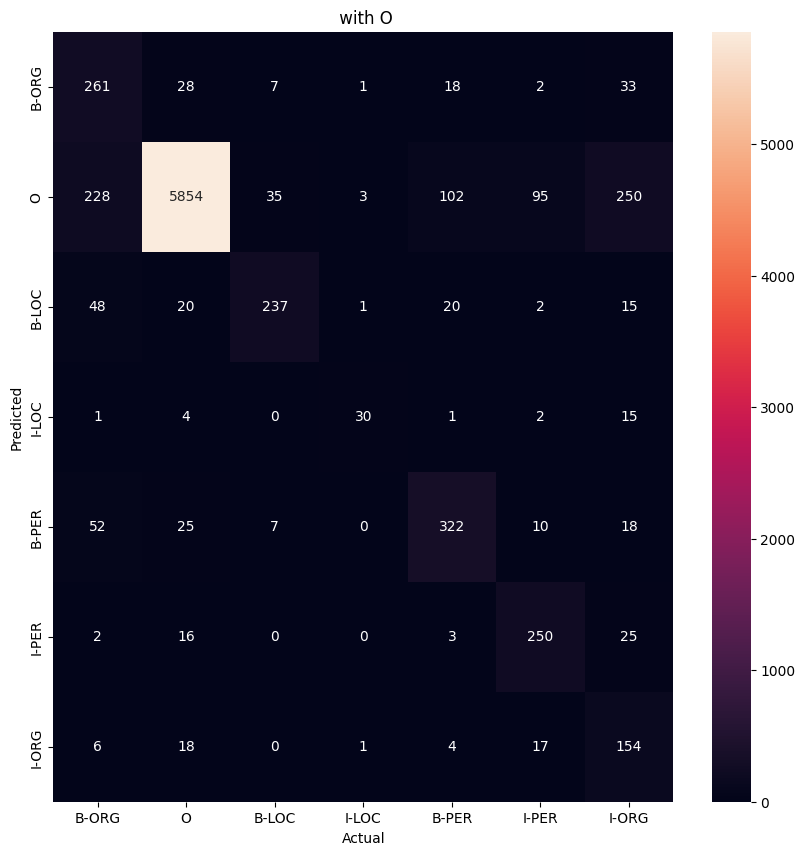

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.44      0.75      0.55       350
       I-LOC       0.83      0.57      0.67        53
       B-PER       0.69      0.74      0.71       434
       B-LOC       0.83      0.69      0.75       343
       I-ORG       0.30      0.77      0.43       200
       I-PER       0.66      0.84      0.74       296

   micro avg       0.55      0.75      0.63      1676
   macro avg       0.62      0.73      0.64      1676
weighted avg       0.62      0.75      0.66      1676



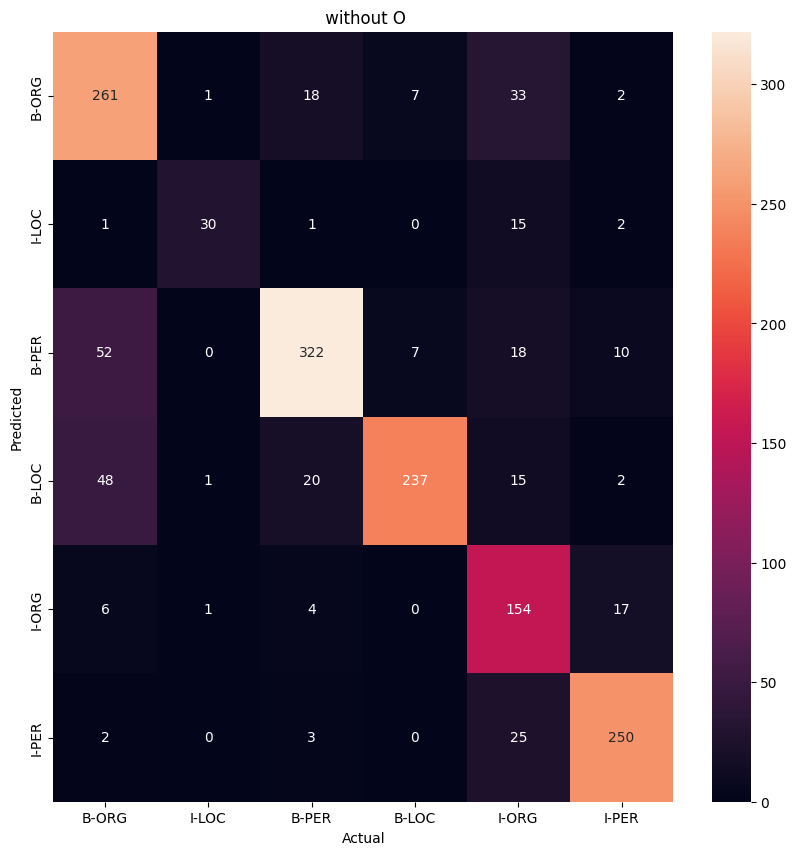

Epochs: 100%|██████████| 10/10 [02:10<00:00, 13.06s/it]


Training completed.
Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.87      0.53      0.66       350
           O       0.93      0.99      0.96      6567
       B-LOC       0.89      0.65      0.75       343
       I-LOC       0.96      0.45      0.62        53
       B-PER       0.78      0.75      0.76       434
       I-PER       0.85      0.77      0.81       296
       I-ORG       0.84      0.31      0.45       200

    accuracy                           0.91      8243
   macro avg       0.87      0.63      0.71      8243
weighted avg       0.91      0.91      0.91      8243



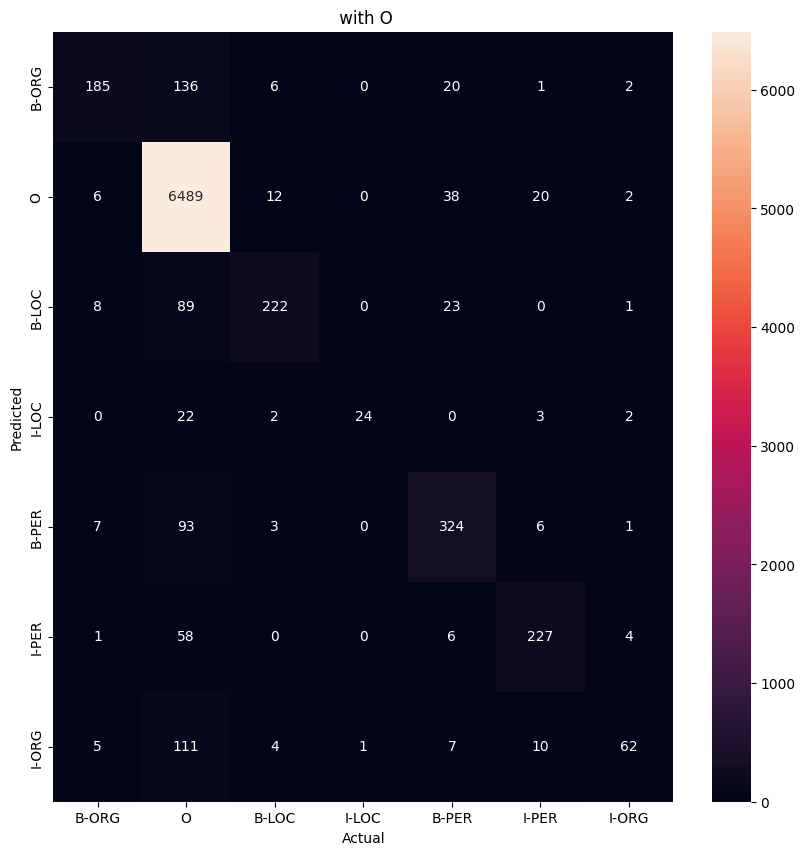

Classification Report:
              precision    recall  f1-score   support

       B-ORG       0.87      0.53      0.66       350
       I-LOC       0.96      0.45      0.62        53
       B-PER       0.78      0.75      0.76       434
       B-LOC       0.89      0.65      0.75       343
       I-ORG       0.84      0.31      0.45       200
       I-PER       0.85      0.77      0.81       296

   micro avg       0.84      0.62      0.71      1676
   macro avg       0.86      0.58      0.67      1676
weighted avg       0.85      0.62      0.70      1676



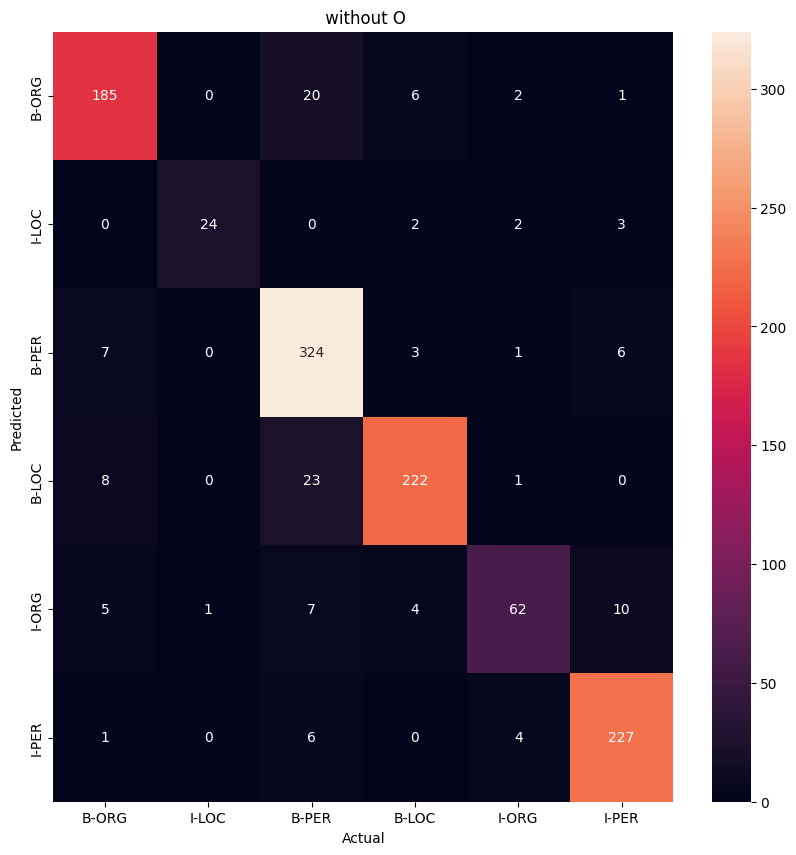

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
####################
# PLACE TESTS HERE #
from google.colab import files

train_ds = read_data("data/train.txt")
dev_ds = read_data("data/dev.txt")
test_ds = read_data("data/test.txt")
def test_read_data():
    result = {
        'lengths': (len(train_ds), len(dev_ds), len(test_ds)),
    }
    return result

vocab = Vocab(train_ds)
def test_vocab():
    sent = vocab.index_words(["I", "am", "Spongebob"])
    return {
        'length': vocab.n_words,
        'tag2id_length': len(vocab.tag2id),
        "Spongebob": sent[2]
    }

train_sequences = prepare_data(train_ds, vocab)
dev_sequences = prepare_data(dev_ds, vocab)
test_sequences = prepare_data(test_ds, vocab)

def test_count_oov():
    return {
        'dev_oov': count_oov(dev_sequences),
        'test_oov': count_oov(test_sequences)
    }

BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

def test_prepare_data_loader():
    return {
        'lengths': (len(dl_train), len(dl_dev), len(dl_test))
    }


def test_NERNet():
    # Extract best model configuration
    hidden_size = best_model_cfg['hidden_size']
    n_layers = best_model_cfg['n_layers']
    directions = best_model_cfg['directions']


    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

def test_glove():
    # Get embeddings
    emb_file = 'glove.6B.300d.txt'
    emb_matrix = get_emb_matrix(emb_file, vocab)

    # Extract best model configuration
    hidden_size = best_model_glove_cfg['hidden_size']
    n_layers = best_model_glove_cfg['n_layers']
    directions = best_model_glove_cfg['directions']

    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)
    initialize_from_pretrained_emb(ner_glove, emb_matrix)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

TESTS = [
    test_read_data,
    test_vocab,
    test_count_oov,
    test_prepare_data_loader,
    test_NERNet,
    test_glove
]

# Run tests and save results
res = {}
for test in TESTS:
    try:
        cur_res = test()
        res.update({test.__name__: cur_res})
    except Exception as e:
        res.update({test.__name__: repr(e)})

with open('results.json', 'w') as f:
    json.dump(res, f, indent=2)

# Download the results.json file
files.download('results.json')

####################
